In [6]:
from __future__ import print_function
%matplotlib inline
import numpy
import matplotlib.pyplot as plt

## **Metode Iteratif**

Metode iteratif adalah metode penyelesaian masalah yang dilakukan dengan cara mengulang langkah perhitungan secara bertahap (berulang-ulang) sampai diperoleh hasil yang mendekati nilai yang diinginkan (konvergen).

Metode berulang mempunyai cara yang berbeda dibandingkan metode langsung.  Jika kita memiliki sistem $A x = b$ kita membentuk prosedur berulang yang menerapkan suatu fungsi, katakanlah $L$ , sehingga
 $$
    \hat{x}^{(k)} = L(\hat{x}^{(k-1)})
$$ 
di mana kita ingin kesalahan antara solusi sebenarnya $x$ dan $\hat{x}^{(k)}$ menjadi nol karena $k \rightarrow \infty$ .  

## Jacobi dan Gauss-Seidel

Metode Jacobi dan Gauss-Seidel adalah pendekatan sederhana untuk memperkenalkan cara berulang untuk menyelesaikan masalah $Ax = b$ ketika $A$ jarang.  Perhatikan kembali permasalahan Poisson $u_{xx} = f(x)$ dan pendekatan beda hingga pada titik $x_i$ 
 $$
    \frac{U_{i-1} - 2 U_i + U_{i+1}}{\Delta x^2} = f(x_i).
$$

Jika kita mengatur ulang ekspresi ini untuk menyelesaikan $U_i$ yang kita miliki
 $$
    U_i = \frac{1}{2} (U_{i+1} + U_{i-1}) - f(x_i) \frac{\Delta x^2}{2}.
$$

Untuk metode langsung kita akan secara bersamaan mencari nilai $U_i$ , $U_{i+1}$ dan $U_{i-1}$ tetapi sebagai gantinya pertimbangkan skema iteratif yang menghitung pembaruan persamaan di atas dengan menggunakan iterasi sebelumnya (nilai yang sudah kita ketahui)
 $$
    U_i^{(k+1)} = \frac{1}{2} (U_{i+1}^{(k)} + U_{i-1}^{(k)}) - f(x_i) \frac{\Delta x^2}{2}.
$$

Karena ini memungkinkan kita mengevaluasi $U_i^{(k + 1)}$ tanpa mengetahui nilai $U_{i+1}^{(k)} + U_{i-1}^{(k)}$, kita langsung mengevaluasi ekspresi ini!  Proses ini disebut **iterasi Jacobi**.  Dapat ditunjukkan bahwa untuk masalah khusus ini, iterasi Jacobi akan menyatu dari tebakan awal $U^{(0)}$ meskipun lambat.

Keuntungan
 - Matriks $A$ tidak pernah disimpan atau dibuat
 - Penyimpanan optimal
 - $\mathcal{O}(m)$ diperlukan per iterasi dimana $m$ adalah jumlah yang tidak diketahui

 ### Contoh
Mari kita coba menyelesaikan masalah sebelumnya di bagian BVP tetapi gunakan iterasi Jacobi untuk menggantikan penyelesaian langsung
 $$
    u_{xx} = e^x, \quad x \in [0, 1] \quad \text{with} \quad u(0) = 0.0, \text{ and } u(1) = 3.
$$


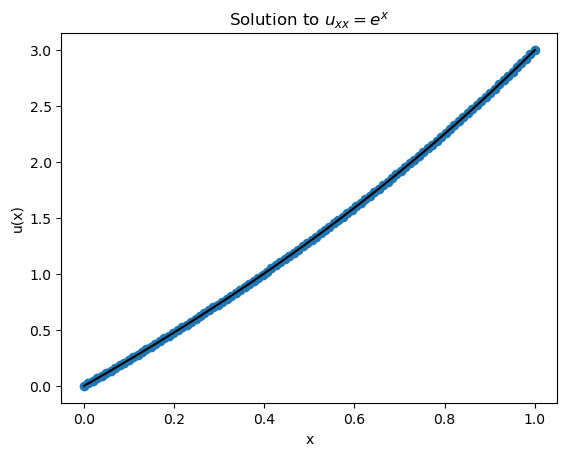

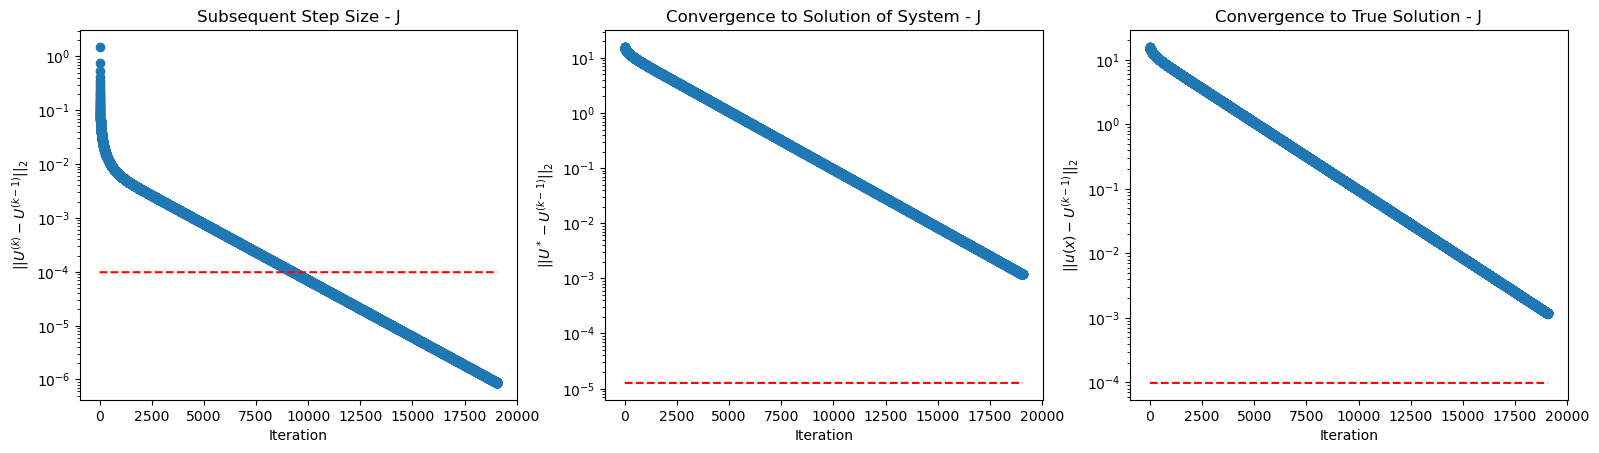

In [42]:
import numpy
import matplotlib.pyplot as plt

# Problem setup
a = 0.0                          # batas kiri domain
b = 1.0                          # batas kanan domain
u_a = 0.0                        # boundary kiri
u_b = 3.0                        # boundary kanan

f = lambda x: numpy.exp(x)       # fungsi sumber
u_true = lambda x: (4.0 - numpy.exp(1.0)) * x - 1.0 + numpy.exp(x)  
# solusi eksak

def U_true(a, b, u_a, u_b, f, m):
    """Compute the solution to the given linear system"""
    x_bc = numpy.linspace(a, b, m + 2)     # grid lengkap
    x = x_bc[1:-1]                         # titik interior
    delta_x = (b - a) / (m + 1)            # jarak grid
    
    # Construct matrix A
    A = numpy.zeros((m, m))                # matriks sistem
    diagonal = numpy.ones(m) / delta_x**2  # nilai diagonal

    A += numpy.diag(diagonal * -2.0, 0)    # diagonal utama
    A += numpy.diag(diagonal[:-1], 1)      # diagonal atas
    A += numpy.diag(diagonal[:-1], -1)     # diagonal bawah

    # Construct RHS
    b = f(x)                               # RHS
    b[0] -= u_a / delta_x**2               # efek boundary kiri
    b[-1] -= u_b / delta_x**2              # efek boundary kanan

    # Solve system
    U = numpy.empty(m + 2)                 # solusi lengkap
    U[0] = u_a                            # boundary kiri
    U[-1] = u_b                           # boundary kanan
    U[1:-1] = numpy.linalg.solve(A, b)     # solusi interior
    
    return U                              # return solusi lengkap

# Descretization
m = 100
x_bc = numpy.linspace(a, b, m + 2)        # grid lengkap
x = x_bc[1:-1]                            # titik interior
delta_x = (b - a) / (m + 1)               # jarak grid

# Expected iterations needed
iterations_J = int(2.0 * numpy.log(delta_x) / numpy.log(1.0 - 0.5 * numpy.pi**2 * delta_x**2))
# estimasi jumlah iterasi Jacobi

# Solve system
U_system = U_true(a, b, u_a, u_b, f, m)   # solusi sistem linear (referensi)
epsilon = numpy.linalg.norm(u_true(x_bc) - U_system, ord=2)  
# error antara solusi eksak dan solusi sistem

# Initial guess for iterations
U_new = numpy.zeros(m + 2)                # tebakan awal
U_new[0] = u_a                            # boundary kiri
U_new[-1] = u_b                           # boundary kanan

convergence_J = numpy.zeros((iterations_J, 2))  # simpan error
step_size_J = numpy.zeros(iterations_J)         # simpan perubahan

for k in range(iterations_J):
    U = U_new.copy()                      # simpan solusi lama
    
    for i in range(1, m + 1):             # loop titik interior
        U_new[i] = 0.5 * (U[i+1] + U[i-1]) - f(x_bc[i]) * delta_x**2 / 2.0  
        # update Jacobi
    
    step_size_J[k] = numpy.linalg.norm(U - U_new, ord=2)  
    # perubahan antar iterasi
    
    convergence_J[k, 0] = numpy.linalg.norm(U_system - U_new, ord=2)  
    # konvergensi ke solusi sistem
    
    convergence_J[k, 1] = numpy.linalg.norm(u_true(x_bc) - U_new, ord=2)  
    # konvergensi ke solusi eksak
        
# Plot result
fig = plt.figure()
axes = fig.add_subplot(1, 1, 1)
axes.plot(x_bc, U, 'o', label="Computed")        # solusi numerik
axes.plot(x_bc, u_true(x_bc), 'k', label="True") # solusi eksak
axes.set_title("Solution to $u_{xx} = e^x$")
axes.set_xlabel("x")
axes.set_ylabel("u(x)")

fig = plt.figure()
fig.set_figwidth(fig.get_figwidth() * 3)

axes = fig.add_subplot(1, 3, 1)
axes.semilogy(list(range(iterations_J)), step_size_J, 'o')  
# perubahan tiap iterasi (log scale)
axes.semilogy(list(range(iterations_J)), numpy.ones(iterations_J) * delta_x**2, 'r--')
axes.set_title("Subsequent Step Size - J")
axes.set_xlabel("Iteration")
axes.set_ylabel("$||U^{(k)} - U^{(k-1)}||_2$")

axes = fig.add_subplot(1, 3, 2)
axes.semilogy(list(range(iterations_J)), convergence_J[:, 0], 'o')  
# konvergensi ke solusi sistem
axes.semilogy(list(range(iterations_J)), numpy.ones(iterations_J) * epsilon, 'r--')
axes.set_title("Convergence to Solution of System - J")
axes.set_xlabel("Iteration")
axes.set_ylabel("$||U^* - U^{(k-1)}||_2$")

axes = fig.add_subplot(1, 3, 3)
axes.semilogy(list(range(iterations_J)), convergence_J[:, 1], 'o')  
# konvergensi ke solusi eksak
axes.semilogy(list(range(iterations_J)), numpy.ones(iterations_J) * delta_x**2, 'r--')
axes.set_title("Convergence to True Solution - J")
axes.set_xlabel("Iteration")
axes.set_ylabel("$||u(x) - U^{(k-1)}||_2$")

plt.show()

Sedikit modifikasi di atas juga mengarah pada metode Gauss-Seidel.  Secara terprogram mudah untuk melihat modifikasinya tetapi dalam iterasi di atas sekarang kita akan melihatnya
 $$
    U_i^{(k+1)} = \frac{1}{2} (U_{i+1}^{(k)} + U_{i-1}^{(k+1)}) - f(x_i) \frac{\Delta x^2}{2}.
$$

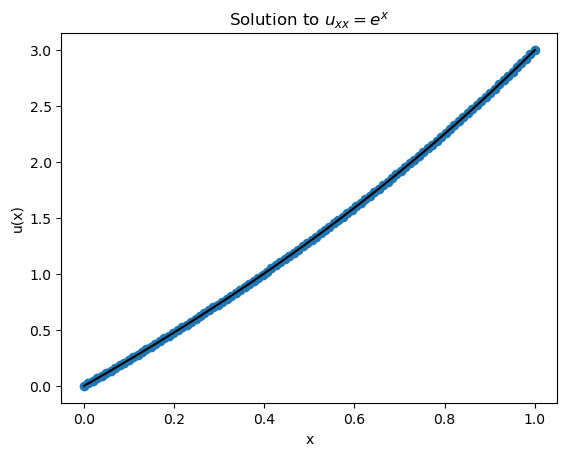

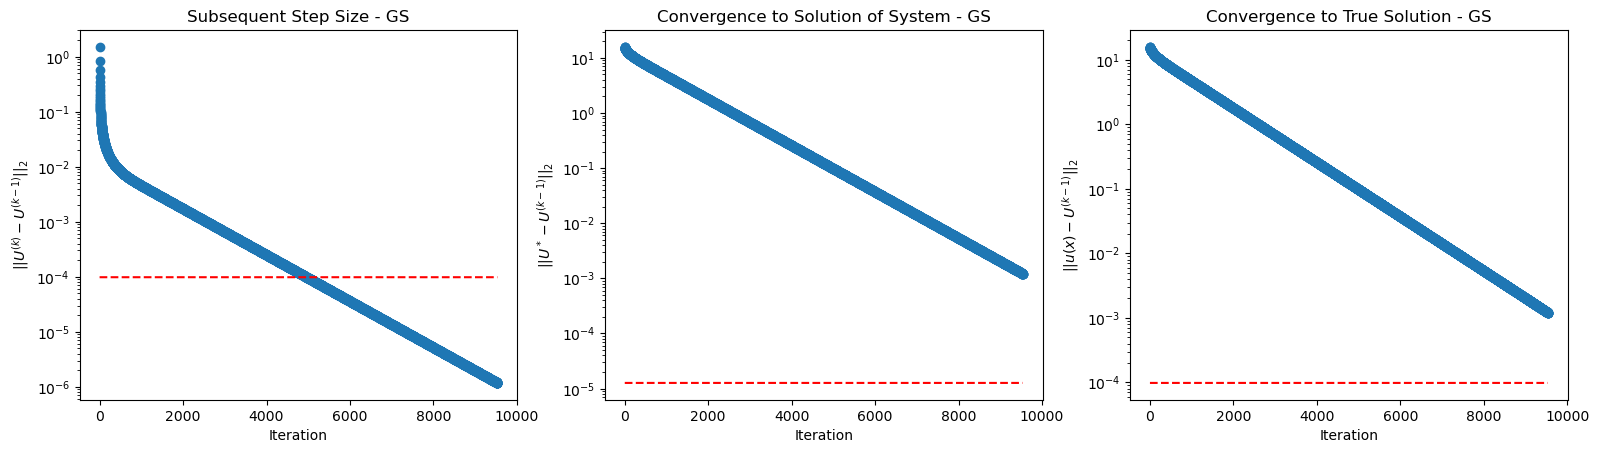

In [43]:
import numpy
import matplotlib.pyplot as plt

# Problem setup
a = 0.0                          # batas kiri domain
b = 1.0                          # batas kanan domain
u_a = 0.0                        # boundary kiri
u_b = 3.0                        # boundary kanan

f = lambda x: numpy.exp(x)       # fungsi sumber
u_true = lambda x: (4.0 - numpy.exp(1.0)) * x - 1.0 + numpy.exp(x)  
# solusi eksak

# Descretization
m = 100
x_bc = numpy.linspace(a, b, m + 2)   # grid lengkap (termasuk boundary)
x = x_bc[1:-1]                       # titik interior
delta_x = (b - a) / (m + 1)          # jarak antar grid

# Expected iterations needed
iterations_GS = int(2.0 * numpy.log(delta_x) / numpy.log(1.0 - numpy.pi**2 * delta_x**2))  
# estimasi jumlah iterasi Gauss-Seidel

# Solve system
U_system = U_true(a, b, u_a, u_b, f, m)  
# solusi sistem linear (referensi dari metode langsung)

epsilon = numpy.linalg.norm(u_true(x_bc) - U_system, ord=2)  
# error antara solusi eksak dan solusi sistem diskrit

# Initial guess for iterations
U = numpy.zeros(m + 2)           # tebakan awal solusi
U[0] = u_a                        # set boundary kiri
U[-1] = u_b                       # set boundary kanan

convergence_GS = numpy.zeros((iterations_GS, 2))  # simpan error konvergensi
step_size_GS = numpy.zeros(iterations_GS)         # simpan perubahan tiap iterasi
success = False                 # flag (tidak dipakai di sini, tapi tidak masalah)

for k in range(iterations_GS):
    U_old = U.copy()            # simpan solusi sebelumnya
    
    for i in range(1, m + 1):   # loop titik interior
        U[i] = 0.5 * (U[i+1] + U[i-1]) - f(x_bc[i]) * delta_x**2 / 2.0  
        # update Gauss-Seidel (langsung pakai nilai terbaru)
    
    convergence_GS[k, 0] = numpy.linalg.norm(U_system - U, ord=2)  
    # konvergensi ke solusi sistem
    
    convergence_GS[k, 1] = numpy.linalg.norm(u_true(x_bc) - U, ord=2)  
    # konvergensi ke solusi eksak
    
    step_size_GS[k] = numpy.linalg.norm(U_old - U, ord=2)  
    # perubahan antar iterasi

# Plot result
fig = plt.figure()
axes = fig.add_subplot(1, 1, 1)
axes.plot(x_bc, U, 'o', label="Computed")        # solusi numerik akhir
axes.plot(x_bc, u_true(x_bc), 'k', label="True") # solusi eksak
axes.set_title("Solution to $u_{xx} = e^x$")
axes.set_xlabel("x")
axes.set_ylabel("u(x)")

fig = plt.figure()
fig.set_figwidth(fig.get_figwidth() * 3)

axes = fig.add_subplot(1, 3, 1)
axes.semilogy(list(range(iterations_GS)), step_size_GS, 'o')  
# perubahan solusi tiap iterasi (log scale)
axes.semilogy(list(range(iterations_GS)), numpy.ones(iterations_GS) * delta_x**2, 'r--')
axes.set_title("Subsequent Step Size - GS")
axes.set_xlabel("Iteration")
axes.set_ylabel("$||U^{(k)} - U^{(k-1)}||_2$")

axes = fig.add_subplot(1, 3, 2)
axes.semilogy(list(range(iterations_GS)), convergence_GS[:, 0], 'o')  
# konvergensi ke solusi sistem diskrit
axes.semilogy(list(range(iterations_GS)), numpy.ones(iterations_GS) * epsilon, 'r--')
axes.set_title("Convergence to Solution of System - GS")
axes.set_xlabel("Iteration")
axes.set_ylabel("$||U^* - U^{(k-1)}||_2$")

axes = fig.add_subplot(1, 3, 3)
axes.semilogy(list(range(iterations_GS)), convergence_GS[:, 1], 'o')  
# konvergensi ke solusi eksak
axes.semilogy(list(range(iterations_GS)), numpy.ones(iterations_GS) * delta_x**2, 'r--')
axes.set_title("Convergence to True Solution - GS")
axes.set_xlabel("Iteration")
axes.set_ylabel("$||u(x) - U^{(k-1)}||_2$")

plt.show()

### Metode Pemisahan Matriks

Salah satu cara untuk melihat Jacobi dan Gauss-Seidel adalah dengan memisahkan matriks $A$ sehingga
 $$
    A = M - N.
$$

Kemudian sistem $A U = b$ dapat dilihat sebagai
 $$
    M U - N U = b \Rightarrow MU = NU + b.
$$
Melihat ini sebagai iterasi yang kita miliki saat itu
 $$
    M U^{(k+1)} = N U^{(k)} + b.
$$ 
Tujuannya kemudian adalah memilih $M$ dan $N$ sedemikian rupa sehingga $M$ berisi $A$ sebanyak mungkin namun tetap lebih mudah dipecahkan dibandingkan sistem aslinya.
Pembaruan yang dihasilkan untuk masing-masingnya kemudian menjadi
 $$
    U^{(k+1)} = M^{-1} N U^{(k)} + M^{-1} b = G U^{(k)} + c
$$ 
di mana $G$ disebut **matriks iterasi** dan $c = M^{-1} b$ .  Kami juga ingin
 $$
    u = G u + c
$$ 
dimana $u$ adalah solusi sebenarnya dari $A u = b$ asli, dengan kata lain $u$ adalah titik tetap dari iterasi.  Apakah titik tetap ini stabil?  Jika radius spektral $\rho(G) < 1$ kita dapat menunjukkan bahwa sebenarnya iterasinya stabil.

Perhatikan kesamaan antara analisis stabilitas kami yang berhubungan dengan $||A^{-1}||$ dan sekarang $G = M^{-1} N$ yang serupa tetapi tidak identik.
Bagi Jacobi, perpecahan adalah hal yang wajar 
 $$
    M = -\frac{2}{\Delta x^2} I, \quad \text{and}\quad N = -\frac{1}{\Delta x^2} \begin{bmatrix}
        0 & 1 & \\
        1 & 0 & 1 \\
          & \ddots & \ddots & \ddots \\
          & & 1 & 0 & 1 \\
          & &   & 1 & 0
    \end{bmatrix}
$$ 
(berpegang teguh pada masalah Poisson).   $M$ sekarang menjadi matriks diagonal dan mudah diselesaikan.

Untuk Gauss-Seidel kita punya
 $$
    M = \frac{1}{\Delta x^2} \begin{bmatrix}
        -2 &  & \\
         1 & -2 &  \\
           & \ddots & \ddots \\
           & & 1 & -2 & \\
           & &   & 1 & -2
    \end{bmatrix} \quad \text{and} \quad 
    N = -\frac{1}{\Delta x^2} \begin{bmatrix}
         0 & 1 & \\
          & 0 & 1 \\
          & & \ddots & \ddots \\
           & &  & 0 & 1\\
           & &   &  & 0
    \end{bmatrix}
$$



### Kriteria Penghentian

Berapa banyak iterasi yang harus kita lakukan?  Biarkan $E^{(k)}$ mewakili kesalahan yang ada pada langkah $k$ .  Jika kita ingin mengurangi kesalahan pada langkah pertama $E^{(0)}$ untuk memesan $\epsilon$ maka kita punya
 $$
    ||E^{(k)}|| \approx \epsilon ||E^{(0)}||.
$$
Berdasarkan asumsi yang sesuai kita dapat membatasi kesalahan dalam 2-norma sebagai
 $$
    ||E^{(k)}||_2 \leq \rho(G)^k ||E^{(0)}||_2.
$$ 
dimana $\rho(G)$ adalah radius spektral dari matriks iterasi.
Kembali ke perkiraan jumlah iterasi, kita dapat menggabungkan dua ekspresi yang melibatkan kesalahan $E$ dengan mengambil $\Delta x \rightarrow 0$ yang memungkinkan kita menulis
 $$
    k \approx \frac{\log \epsilon}{\log \rho(G)}
$$ 
dengan mempertimbangkan konvergensi kesalahan.

Memilih $\epsilon$ agak rumit tetapi salah satu kriteria alami yang digunakan adalah $\epsilon = \mathcal{O}(\Delta x^2)$ karena diskritisasi asli kami akurat tingkat ke-2.  Hal ini mengarah ke
 $$
    k = \frac{2 \log \Delta x}{\log \rho}.
$$ 
Hal ini juga memungkinkan kami memperkirakan jumlah total operasi yang perlu digunakan.

Untuk Jacobi kami memiliki radius spektral $G$ sebagai
 $$
    \rho_J \approx 1 - \frac{1}{2} \pi^2 \Delta x^2.
$$ 
jadi itu
 $$
    k = \mathcal{O}(m^2 \log m) \quad \text{as} \quad m \rightarrow \infty.
$$

Menggabungkan ini dengan jumlah operasi per iterasi sebelumnya, kami menemukan bahwa Jacobi akan menghasilkan pekerjaan $\mathcal{O}(m^3 \log m)$ yang tidak terlalu menjanjikan.

Untuk dua dimensi kami memiliki $\mathcal{O}(m^4 \log m)$ sehingga dibandingkan dengan eliminasi Gaussian, pendekatan ini tidak ideal.

Bagaimana dengan Gauss-Seidel?  Di sini radius spektralnya kira-kira
 $$
    \rho_{GS} \approx 1 - \pi^2 \Delta x^2
$$ 
jadi itu
 $$
    k = \frac{2 \times \log \Delta x}{\log (1 - \pi^2 \Delta x^2)}
$$ 
yang masih tidak memberikan keuntungan apa pun dibandingkan pemecah langsung.  Hal ini menunjukkan bahwa Gauss-Seidel sebenarnya menyatu lebih cepat karena perbedaan faktor 2 antara $\rho_J$ dan $\rho_{GS}$ .



## Relaksasi Berlebihan Berturut-turut (SOR)


Jika dilihat pada iterasi Gauss-Seidel ternyata menggerakkan $U$ ke arah yang benar ke $u$ namun sangat konservatif dalam besarannya.  Jika sebaliknya kita melakukannya
 $$\begin{aligned}
    U^{GS}_i &= \frac{1}{2} \left(U^{(k+1)}_{i-1} + U^{(k)}_{i+1} - \Delta x^2 f_i\right) \\
    U^{(k+1)}_i &= U_i^{(k)} + \omega \left( U_i^{GS} - U_i^{(k)}\right )
\end{aligned}$$ 
di mana kita bisa memilih $\omega$ kita bisa melakukan lebih baik.

Jika $\omega = 1$ maka kita mendapatkan kembali Gauss-Seidel.  

Jika $\omega < 1$ kita bergerak lebih sedikit dan menyatu lebih lambat (walaupun terkadang digunakan untuk multigrid dengan nama **underrelaxation**).  

Jika $\omega > 1$ maka kita melangkah lebih jauh dari yang disarankan Gauss-Seidel dan metode apa pun yang menggunakan $\omega > 1$ dikenal sebagai **relaksasi berlebihan berturut-turut** (SOR).

Kita juga dapat menulis ini sebagai metode pemisahan matriks.  Kita dapat menggabungkan rumus dua langkah di atas untuk mencarinya
 $$
    U^{(k+1)}_i = \frac{\omega}{2} \left( U^{(k+1)}_{i-1} + U^{(k)}_{i+1} - \Delta x^2 f_i \right ) + (1 - \omega) U_i^{(k)}
$$ 
sesuai dengan pemisahan matriks
 $$
    M = \frac{1}{\omega} (D - \omega L) \quad \text{and} \quad N = \frac{1}{\omega} ((1-\omega) D + \omega U)
$$ 
dimana $D$ adalah diagonal matriks $A$ , dan $L$ dan $U$ adalah bagian segitiga bawah dan atas tanpa diagonal $A$ .

Dapat ditunjukkan bahwa memilih $\omega$ sedemikian rupa sehingga $0 < \omega < 2$ metode SOR menyatu.
Ternyata kita juga dapat menemukan $\omega$ yang optimal untuk berbagai kelas soal.  Untuk permasalahan Poisson pada sejumlah dimensi ruang misalnya dapat ditunjukkan bahwa metode SOR konvergen secara optimal jika
 $$
    \omega_{opt} = \frac{2}{1 + \sin(\pi \Delta x)} \approx 2 - 2 \pi \Delta x.
$$

Bagaimana dengan jumlah iterasi?  Kita dapat mengikuti taktik yang sama seperti sebelumnya dengan radius spektral $G_{SOR}$ sekarang
 $$
    \rho = \omega_{opt} - 1 \approx 1 - 2 \pi \Delta x.
$$

Hal ini menyebabkan jumlah iterasi sebesar
 $$
    k = \mathcal{O}(m \log m)
$$ 
jauh lebih baik daripada Gauss-Seidel saja!




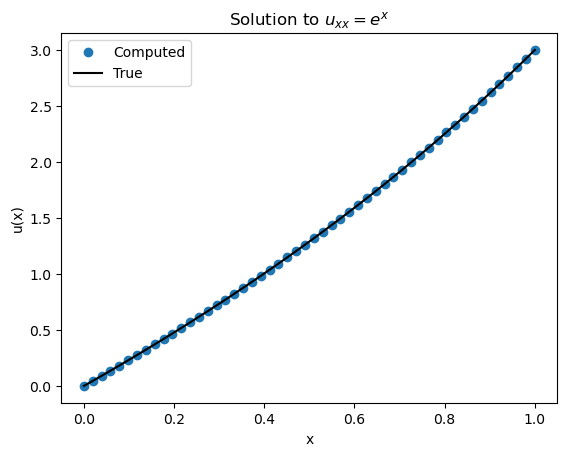

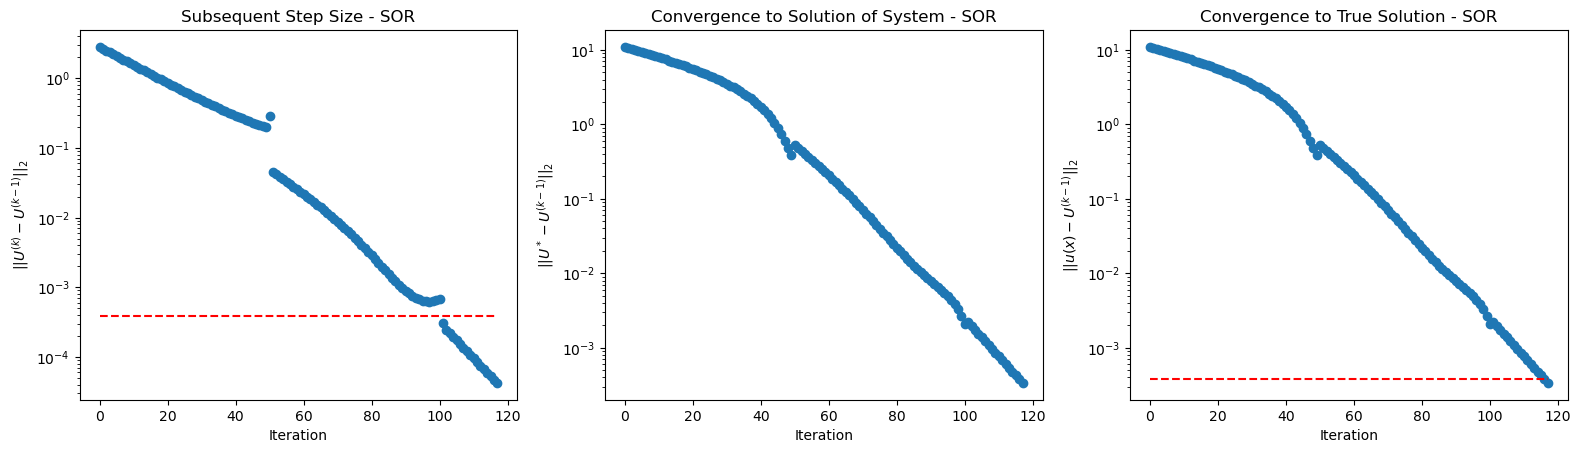

In [9]:
# ===============================
# PROBLEM SETUP
# ===============================
a = 0.0          # batas kiri domain
b = 1.0          # batas kanan domain
u_a = 0.0        # nilai solusi di x = a (boundary condition)
u_b = 3.0        # nilai solusi di x = b

f = lambda x: numpy.exp(x)  
# fungsi sumber pada PDE: u_xx = e^x

u_true = lambda x: (4.0 - numpy.exp(1.0)) * x - 1.0 + numpy.exp(x)  
# solusi eksak dari persamaan diferensial

# ===============================
# DISCRETIZATION (FINITE DIFFERENCE)
# ===============================
m = 50  
# jumlah titik interior (grid semakin rapat → solusi makin akurat)

x_bc = numpy.linspace(a, b, m + 2)  
# grid lengkap (termasuk boundary)

x = x_bc[1:-1]  
# hanya titik interior (tanpa boundary)

delta_x = (b - a) / (m + 1)  
# jarak antar grid

# ===============================
# PARAMETER SOR
# ===============================
omega = 2.0 / (1.0 + numpy.sin(numpy.pi * delta_x))  
# parameter relaksasi optimal → mempercepat konvergensi metode SOR

# ===============================
# ESTIMASI JUMLAH ITERASI
# ===============================
iterations_SOR = int(2.0 * numpy.log(delta_x) / numpy.log(1.0 - 2.0 * numpy.pi * delta_x)) * 2  
# estimasi jumlah iterasi agar solusi cukup konvergen

# ===============================
# SOLUSI SISTEM (SEBAGAI PEMBANDING)
# ===============================
U_system = u_true(x_bc) 
# solusi sistem linear (dianggap solusi numerik "benar")

epsilon = numpy.linalg.norm(u_true(x_bc) - U_system, ord=2)  
# error antara solusi eksak dan solusi sistem

# ===============================
# INISIALISASI ITERASI
# ===============================
U = numpy.zeros(m + 2)  
# tebakan awal solusi

U[0] = u_a  
U[-1] = u_b  
# memasukkan kondisi batas

step_size_SOR = numpy.zeros(iterations_SOR)  
# menyimpan perubahan solusi tiap iterasi

convergence_SOR = numpy.zeros((iterations_SOR, 2))  
# kolom 0 → error ke solusi sistem
# kolom 1 → error ke solusi eksak

# ===============================
# ITERASI SOR
# ===============================
for k in range(iterations_SOR):
    U_old = U.copy()  # simpan solusi sebelumnya
    
    for i in range(1, m + 1):
        # update Gauss-Seidel
        U_gs = 0.5 * (U[i-1] + U[i+1] - delta_x**2 * f(x_bc[i]))
        
        # update SOR (relaksasi)
        U[i] += omega * (U_gs - U[i])

    # perubahan solusi antar iterasi
    step_size_SOR[k] = numpy.linalg.norm(U_old - U, ord=2)

    # error terhadap solusi sistem
    convergence_SOR[k, 0] = numpy.linalg.norm(U_system - U, ord=2)

    # error terhadap solusi eksak
    convergence_SOR[k, 1] = numpy.linalg.norm(u_true(x_bc) - U, ord=2)

# ===============================
# PLOT SOLUSI
# ===============================
fig = plt.figure()
axes = fig.add_subplot(1, 1, 1)

axes.plot(x_bc, U, 'o', label="Computed")  
# hasil solusi numerik

axes.plot(x_bc, u_true(x_bc), 'k', label="True")  
# solusi eksak

axes.set_title("Solution to $u_{xx} = e^x$")
axes.set_xlabel("x")
axes.set_ylabel("u(x)")
axes.legend()

# ===============================
# PLOT KONVERGENSI
# ===============================
fig = plt.figure()
fig.set_figwidth(fig.get_figwidth() * 3)

# ---- (1) STEP SIZE ----
axes = fig.add_subplot(1, 3, 1)
axes.semilogy(range(iterations_SOR), step_size_SOR, 'o')  
# perubahan solusi tiap iterasi (harus menurun)

axes.semilogy(range(iterations_SOR), numpy.ones(iterations_SOR) * delta_x**2, 'r--')  
# batas error teoritis

axes.set_title("Subsequent Step Size - SOR")
axes.set_xlabel("Iteration")
axes.set_ylabel("$||U^{(k)} - U^{(k-1)}||_2$")

# ---- (2) KONVERGENSI KE SOLUSI SISTEM ----
axes = fig.add_subplot(1, 3, 2)
axes.semilogy(range(iterations_SOR), convergence_SOR[:, 0], 'o')  
# error terhadap solusi sistem linear

axes.semilogy(range(iterations_SOR), numpy.ones(iterations_SOR) * epsilon, 'r--')  
# batas error minimum

axes.set_title("Convergence to Solution of System - SOR")
axes.set_xlabel("Iteration")
axes.set_ylabel("$||U^* - U^{(k-1)}||_2$")

# ---- (3) KONVERGENSI KE SOLUSI EKSAK ----
axes = fig.add_subplot(1, 3, 3)
axes.semilogy(range(iterations_SOR), convergence_SOR[:, 1], 'o')  
# error terhadap solusi eksak

axes.semilogy(range(iterations_SOR), numpy.ones(iterations_SOR) * delta_x**2, 'r--')  

axes.set_title("Convergence to True Solution - SOR")
axes.set_xlabel("Iteration")
axes.set_ylabel("$||u(x) - U^{(k-1)}||_2$")

plt.show()

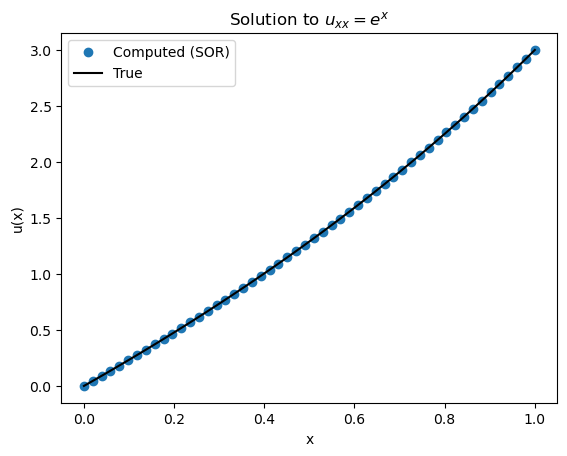

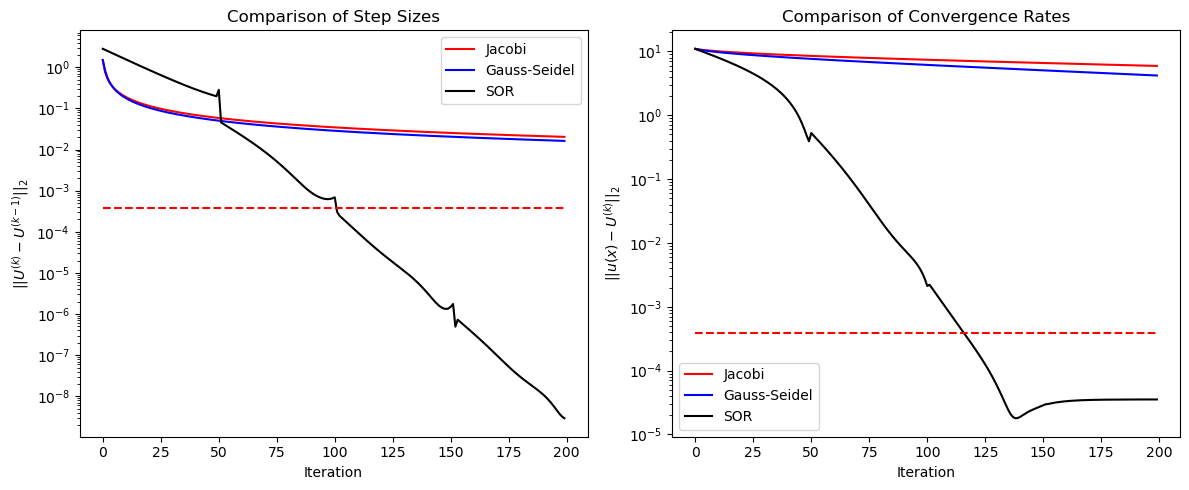

In [13]:
# ===============================
# IMPORT LIBRARY
# ===============================
import numpy as np              # library numerik
import matplotlib.pyplot as plt # library plotting

# ===============================
# PROBLEM SETUP
# ===============================
a, b = 0.0, 1.0                # domain [a, b]
u_a, u_b = 0.0, 3.0            # kondisi batas

f = lambda x: np.exp(x)        # fungsi sumber u_xx = e^x
u_true = lambda x: (4.0 - np.exp(1.0)) * x - 1.0 + np.exp(x)  # solusi eksak

# ===============================
# DISCRETIZATION
# ===============================
m = 50                         # jumlah titik interior
x_bc = np.linspace(a, b, m + 2) # grid termasuk boundary
delta_x = (b - a) / (m + 1)    # jarak grid

U_system = u_true(x_bc)        # solusi eksak sebagai pembanding

# ===============================
# PARAMETER
# ===============================
omega = 2.0 / (1.0 + np.sin(np.pi * delta_x))  # parameter SOR optimal
iterations = 200           # jumlah iterasi (disamakan untuk semua metode)

# ===============================
# JACOBI METHOD
# ===============================
U = np.zeros(m + 2)        # inisialisasi solusi
U[0], U[-1] = u_a, u_b     # set boundary condition

step_size_J = np.zeros(iterations)            # simpan perubahan solusi
convergence_J = np.zeros((iterations, 2))     # simpan error

for k in range(iterations):
    U_old = U.copy()       # simpan solusi lama
    U_new = U.copy()       # array baru untuk update Jacobi

    for i in range(1, m + 1):
        # rumus finite difference (Jacobi)
        U_new[i] = 0.5 * (U[i-1] + U[i+1] - delta_x**2 * f(x_bc[i]))

    U = U_new.copy()       # update solusi

    step_size_J[k] = np.linalg.norm(U_old - U)                  # perubahan antar iterasi
    convergence_J[k, 0] = np.linalg.norm(U_system - U)          # error ke solusi sistem
    convergence_J[k, 1] = np.linalg.norm(u_true(x_bc) - U)      # error ke solusi eksak

# ===============================
# GAUSS-SEIDEL METHOD
# ===============================
U = np.zeros(m + 2)
U[0], U[-1] = u_a, u_b

step_size_GS = np.zeros(iterations)
convergence_GS = np.zeros((iterations, 2))

for k in range(iterations):
    U_old = U.copy()

    for i in range(1, m + 1):
        # update langsung (Gauss-Seidel)
        U[i] = 0.5 * (U[i-1] + U[i+1] - delta_x**2 * f(x_bc[i]))

    step_size_GS[k] = np.linalg.norm(U_old - U)
    convergence_GS[k, 0] = np.linalg.norm(U_system - U)
    convergence_GS[k, 1] = np.linalg.norm(u_true(x_bc) - U)

# ===============================
# SOR METHOD
# ===============================
U = np.zeros(m + 2)
U[0], U[-1] = u_a, u_b

step_size_SOR = np.zeros(iterations)
convergence_SOR = np.zeros((iterations, 2))

for k in range(iterations):
    U_old = U.copy()

    for i in range(1, m + 1):
        # Gauss-Seidel step
        U_gs = 0.5 * (U[i-1] + U[i+1] - delta_x**2 * f(x_bc[i]))
        
        # relaksasi SOR
        U[i] += omega * (U_gs - U[i])

    step_size_SOR[k] = np.linalg.norm(U_old - U)
    convergence_SOR[k, 0] = np.linalg.norm(U_system - U)
    convergence_SOR[k, 1] = np.linalg.norm(u_true(x_bc) - U)

# ===============================
# PLOT SOLUSI
# ===============================
plt.figure()
plt.plot(x_bc, U, 'o', label="Computed (SOR)")  # solusi numerik
plt.plot(x_bc, u_true(x_bc), 'k', label="True") # solusi eksak
plt.title("Solution to $u_{xx} = e^x$")
plt.xlabel("x")
plt.ylabel("u(x)")
plt.legend()

# ===============================
# PLOT PERBANDINGAN
# ===============================
fig = plt.figure(figsize=(12,5))

# ---- STEP SIZE ----
plt.subplot(1,2,1)
plt.semilogy(step_size_J, 'r', label="Jacobi")         # Jacobi
plt.semilogy(step_size_GS, 'b', label="Gauss-Seidel")  # GS
plt.semilogy(step_size_SOR, 'k', label="SOR")          # SOR
plt.semilogy(np.ones(iterations)*delta_x**2, 'r--')    # garis referensi
plt.title("Comparison of Step Sizes")
plt.xlabel("Iteration")
plt.ylabel("$||U^{(k)} - U^{(k-1)}||_2$")
plt.legend()

# ---- KONVERGENSI ----
plt.subplot(1,2,2)
plt.semilogy(convergence_J[:,1], 'r', label="Jacobi")         # error Jacobi
plt.semilogy(convergence_GS[:,1], 'b', label="Gauss-Seidel")  # error GS
plt.semilogy(convergence_SOR[:,1], 'k', label="SOR")          # error SOR
plt.semilogy(np.ones(iterations)*delta_x**2, 'r--')           # batas error
plt.title("Comparison of Convergence Rates")
plt.xlabel("Iteration")
plt.ylabel("$||u(x) - U^{(k)}||_2$")
plt.legend()

plt.tight_layout()  # rapikan layout
plt.show()          # tampilkan plot

## Metode Penurunan

Satu kasus matriks khusus dapat menerima cara lain yang ampuh untuk melakukan iterasi ke solusi.  Suatu matriks dikatakan **pasti positif simetris** (SPD) jika 
 $$
    x^T A x > 0 \quad \forall \quad x \neq 0.
$$

Periksa untuk melihat apakah 
 $$
    A = \begin{bmatrix}
        2 &-1 &0 &0 \\
        -1 & 2 & -1 & 0 \\
        0 & -1 & 2 & -1 \\
        0 & 0 & -1 & 2
    \end{bmatrix}
$$ 
adalah pasti positif simetris.

Sekarang tentukan fungsi $\phi: \mathbb R^m \rightarrow \mathbb R$ sedemikian rupa
 $$
    \phi(u) = \frac{1}{2} u^T A u - u^T f.
$$ 
Ini adalah fungsi kuadrat dalam variabel $u_i$ dan dalam kasus di mana $m = 2$ membentuk mangkuk parabola.  Karena ini adalah fungsi kuadrat, maka ada minimum uniknya, $u^\ast$ .

Mari kita lihat bagaimana pendekatan terhadap masalah seperti ini membantu kita:

Untuk kasus $m = 2$ tuliskan fungsi $\phi(u)$.

$$
    \phi(u) = \frac{1}{2} (A_{11} u_1^2 + A_{12} u_1 u_2 + A_{21} u_1 u_2 + A_{22} u^2_2) - u_1 f_1 - u_2 f_2
$$

Properti matriks $A$ manakah yang menyederhanakan ekspresi di atas?

Simetri!  Ini menyiratkan bahwa $A_{21} = A_{12}$ dan ekspresi di atas disederhanakan menjadi 
$$
    \phi(u) = \frac{1}{2} (A_{11} u_1^2 + 2 A_{12} u_1 u_2 + A_{22} u^2_2) - u_1 f_1 - u_2 f_2
$$

Sekarang tuliskan dua ekspresi yang ketika dievaluasi pada $u^\ast$ identik dengan 0 yang menyatakan bahwa $u^\ast$ meminimalkan $\phi(u)$ .

Karena $u^\ast$ meminimalkan $\phi(u)$, kita tahu bahwa turunan pertamanya minimal harus nol:

$$\begin{aligned}
       \frac{\partial \phi}{\partial u_1} &= A_{11} u_1 + A_{12} u_2 - f_1 = 0 \\
       \frac{\partial \phi}{\partial u_1} &= A_{21} u_1 + A_{22} u_2 - f_2 = 0
\end{aligned}$$ 

Perhatikan bahwa persamaan ini dapat ditulis ulang sebagai
$$
       A u = f.
$$

Oleh karena itu $\min \phi$ setara dengan menyelesaikan $A u = f$ !

Ini adalah jenis reformulasi umum untuk banyak permasalahan yang mungkin lebih mudah untuk memperlakukan persamaan tertentu sebagai masalah minimalisasi daripada menyelesaikannya secara langsung.

Perhatikan bahwa ini bukanlah matriks yang telah kita gunakan untuk masalah Poisson sejauh ini, yang sebenarnya adalah matriks pasti negatif simetris meskipun metode yang sama juga dapat digunakan.  Dalam hal ini kami sebenarnya ingin mencari maksimum $\phi$, selain itu semuanya sama.

Perhatikan juga bahwa jika $A$ tidak terbatas maka nilai eigen $A$ akan berubah tanda dan alih-alih nilai minimum atau maksimum yang stabil, kita memiliki titik pelana yang jauh lebih sulit untuk ditangani (misalnya GMRES).

### Metode Penurunan Paling Curam

Jadi sekarang kita beralih mencari $u^\ast$ yang meminimalkan fungsi $\phi(u)$ .  Pendekatan paling sederhana untuk hal ini disebut **metode penurunan paling curam** yang menemukan arah gradien terbesar $\phi(u)$ dan menuju ke arah tersebut.

Secara matematis kita punya
 $$
    u^{(k+1)} = u^{(k)} - \alpha^{(k)} \nabla \phi(u^{(k)})
$$ 
dimana $\alpha^{(k)}$ akan menjadi ukuran langkah yang dipilih ke arah yang ingin kita tuju.

Kita dapat menemukan $\alpha$ dengan
 $$
    \alpha^{(k)} = \min_{\alpha \in \mathbb R} \phi\left(u^{(k)} - \alpha \nabla \phi(u^{(k)}\right),
$$ 
yaitu $\alpha$ yang membawa kita cukup jauh sehingga jika kita melangkah lebih jauh $\phi$ akan meningkat.

Artinya $\alpha^{(k)} \geq 0$ dan $\alpha^{(k)} = 0$ hanya jika kita berada pada minimum $\phi$ .  Kita dapat menghitung gradien $\phi$ sebagai
 $$
    \nabla \phi(u^{(k)}) = A u^{(k)} - f \equiv -r^{(k)}
$$ 
dimana $r^{(k)}$ adalah sisa yang didefinisikan sebagai
 $$
    r^{(k)} = f - A u^{(k)}.
$$

Melihat kembali definisi $\alpha^{(k)}$ kemudian mengarah pada kesimpulan bahwa $\alpha$ yang akan meminimalkan ekspresi adalah yang memenuhi
 $$
    \frac{\text{d} \phi(\alpha)}{\text{d} \alpha} = 0. 
$$ 

Untuk menemukan ini, perhatikan itu
 $$
    \phi(u + \alpha r) = \left(\frac{1}{2} u^T A u - u^T f \right) + \alpha(r^T A u - r^T f) + \frac{1}{2} \alpha^2 r^T A r
$$ 
sehingga turunannya menjadi
 $$
    \frac{\text{d} \phi(\alpha)}{\text{d} \alpha} = r^T A u - r^T f + \alpha r^T A r
$$ 

Menyetel ini ke nol akan menghasilkan
 $$
    \alpha = \frac{r^T r}{r^T A r}.
$$


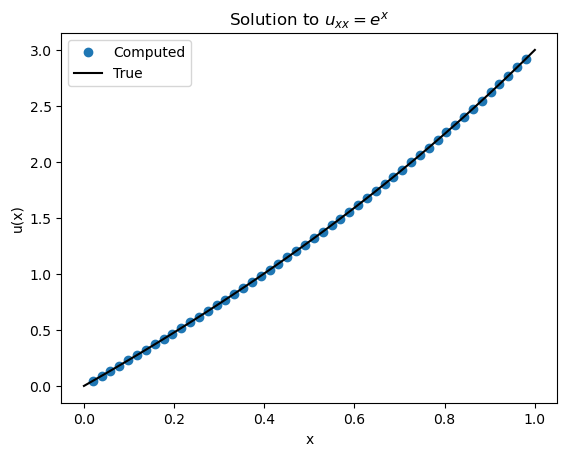

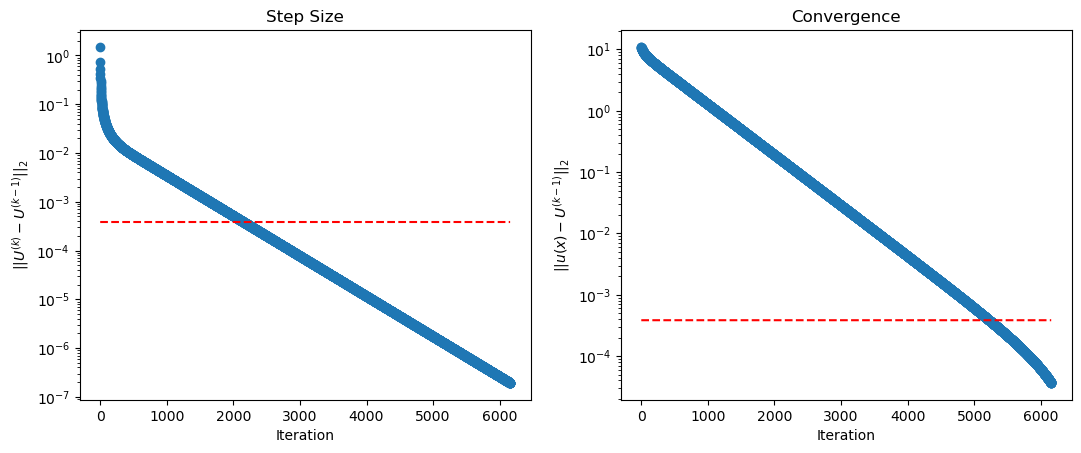

In [15]:
# ===============================
# IMPORT LIBRARY
# ===============================
import numpy as np
import matplotlib.pyplot as plt

# ===============================
# PROBLEM SETUP
# ===============================
a = 0.0
b_dom = 1.0                 # ganti nama agar tidak bentrok dengan vektor b
u_a = 0.0
u_b = 3.0

f = lambda x: np.exp(x)     # fungsi sumber
u_true = lambda x: (4.0 - np.exp(1.0)) * x - 1.0 + np.exp(x)  # solusi eksak

# ===============================
# DISCRETIZATION
# ===============================
m = 50
x_bc = np.linspace(a, b_dom, m + 2)   # grid lengkap
x = x_bc[1:-1]                        # titik interior
delta_x = (b_dom - a) / (m + 1)       # jarak grid

# ===============================
# CONSTRUCT MATRIX A
# ===============================
A = np.zeros((m, m))                  # matriks sistem
diagonal = np.ones(m) / delta_x**2

A += np.diag(diagonal * 2.0, 0)       # diagonal utama
A += np.diag(-diagonal[:-1], 1)       # diagonal atas
A += np.diag(-diagonal[:-1], -1)      # diagonal bawah

# ===============================
# RIGHT HAND SIDE (RHS)
# ===============================
b = -f(x)                             # vektor RHS
b[0] += u_a / delta_x**2              # pengaruh boundary kiri
b[-1] += u_b / delta_x**2             # pengaruh boundary kanan

# ===============================
# PARAMETER STEEPEST DESCENT
# ===============================
MAX_ITERATIONS = 10000
tolerance = 1e-3

# ===============================
# INISIALISASI
# ===============================
U = np.zeros(m)                       # tebakan awal (lebih aman dari empty)
convergence_SD = np.zeros(MAX_ITERATIONS)  # simpan error
step_size_SD = np.zeros(MAX_ITERATIONS)    # simpan step size

success = False

# ===============================
# ITERASI STEEPEST DESCENT
# ===============================
for k in range(MAX_ITERATIONS):
    r = b - np.dot(A, U)              # residual r = b - AU
    
    if np.linalg.norm(r, ord=2) < tolerance:  # cek konvergensi
        success = True
        break
        
    alpha = np.dot(r, r) / np.dot(r, np.dot(A, r))  
    # langkah optimal (step size)

    U = U + alpha * r                 # update solusi

    step_size_SD[k] = np.linalg.norm(alpha * r, ord=2)  
    # perubahan solusi

    convergence_SD[k] = np.linalg.norm(u_true(x) - U, ord=2)  
    # error terhadap solusi eksak
        
# ===============================
# CEK KONVERGENSI
# ===============================
if not success:
    print("Iteration failed to converge!")
    print(convergence_SD[-1])
else:
    # ===============================
    # PLOT SOLUSI
    # ===============================
    fig = plt.figure()
    axes = fig.add_subplot(1, 1, 1)
    
    axes.plot(x, U, 'o', label="Computed")          # solusi numerik (interior)
    axes.plot(x_bc, u_true(x_bc), 'k', label="True") # solusi eksak
    
    axes.set_title("Solution to $u_{xx} = e^x$")
    axes.set_xlabel("x")
    axes.set_ylabel("u(x)")
    axes.legend()

    # ===============================
    # PLOT KONVERGENSI
    # ===============================
    fig = plt.figure()
    fig.set_figwidth(fig.get_figwidth() * 2)
    
    # ---- STEP SIZE ----
    axes = fig.add_subplot(1, 2, 1)
    axes.semilogy(range(k), step_size_SD[:k], 'o')  
    # perubahan solusi tiap iterasi

    axes.semilogy(range(k), np.ones(k) * delta_x**2, 'r--')  
    # garis referensi error

    axes.set_title("Step Size")
    axes.set_xlabel("Iteration")
    axes.set_ylabel("$||U^{(k)} - U^{(k-1)}||_2$")

    # ---- KONVERGENSI ----
    axes = fig.add_subplot(1, 2, 2)
    axes.semilogy(range(k), convergence_SD[:k], 'o')  
    # error terhadap solusi eksak

    axes.semilogy(range(k), np.ones(k) * delta_x**2, 'r--')

    axes.set_title("Convergence")
    axes.set_xlabel("Iteration")
    axes.set_ylabel("$||u(x) - U^{(k-1)}||_2$")

    plt.show()

#### Konvergensi Penurunan Paling Curam

Apa yang mengontrol konvergensi pada turunan paling curam?  Ternyata bentuk mangkuk parabola yang dibentuk oleh $\phi$ menjadi faktor utama penentu konvergensi turunan paling curam.  

Misalnya, jika $A$ adalah kelipatan skalar dari identitas maka elips ini sebenarnya adalah lingkaran dan penurunan paling curam menyatu dalam langkah $m$.  Jika $A$ tidak mengarah ke lingkaran, konvergensi didasarkan pada rasio antara sumbu semi-mayor dan semi-minor dari elips dimensi $m$ yang dihasilkan.  

Hal ini dikendalikan oleh nilai eigen terkecil dan terbesar dari matriks $A$ sehingga penurunan paling curam menjadi semakin sulit seiring dengan meningkatnya $m$ untuk masalah Poisson.  Perhatikan bahwa ini juga berkaitan dengan nomor kondisi matriks dalam norma $\ell_2$.

Iteration count: 1
Iteration count: 8
Iteration count: 83


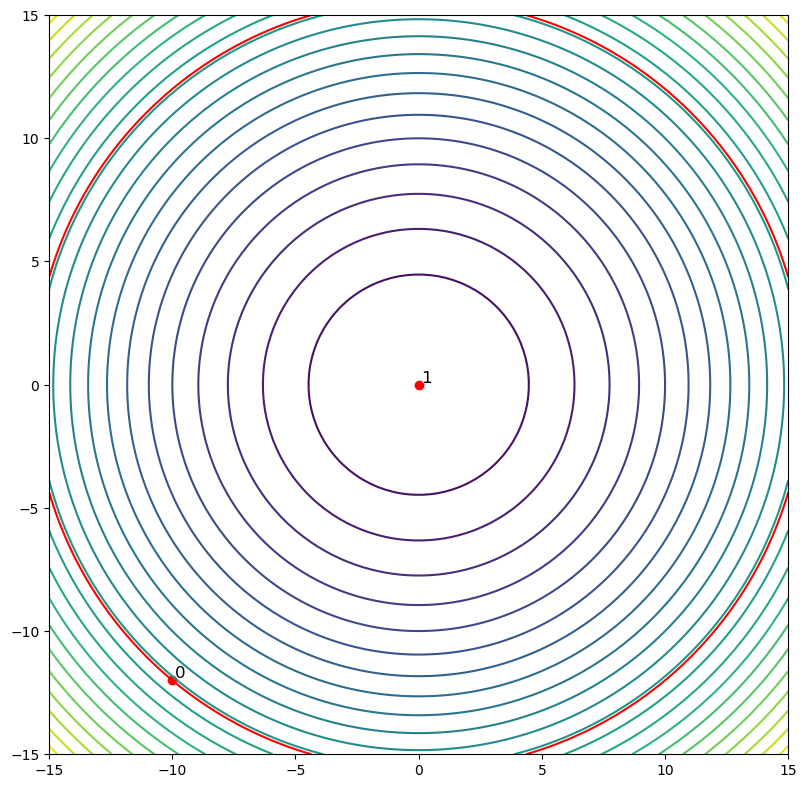

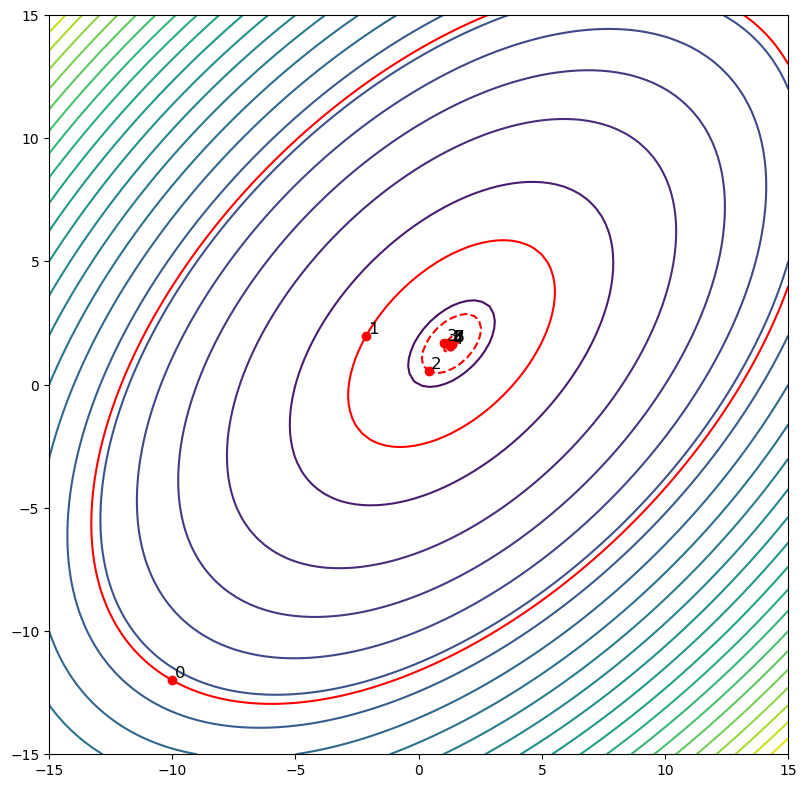

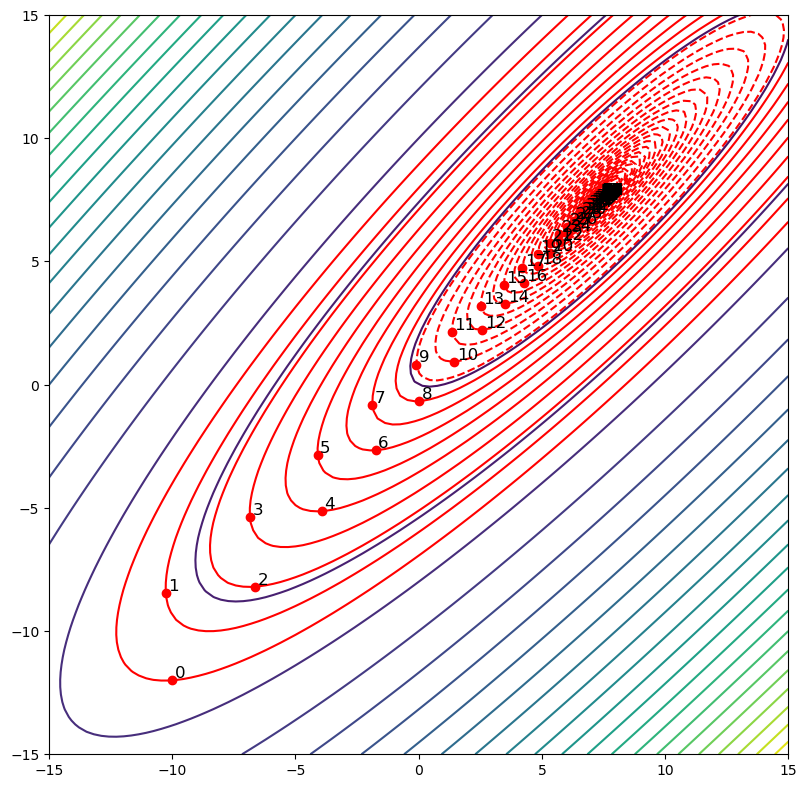

In [19]:
def steepest_descent(A, U, b, axes):
    MAX_ITERATIONS = 10000              # maksimum jumlah iterasi
    tolerance = 1e-3                    # batas toleransi konvergensi
    success = False                     # penanda apakah konvergen
    iteration_locations = []            # menyimpan posisi tiap iterasi
    for k in range(MAX_ITERATIONS):     
        axes.text(U[0] + 0.1, U[1] + 0.1, str(k), fontsize=12)  # tampilkan nomor iterasi di plot
        axes.plot(U[0], U[1], 'ro')     # plot titik iterasi (warna merah)
        iteration_locations.append(U)   # simpan posisi titik saat ini
        r = b - numpy.dot(A, U)         # residual (arah penurunan / gradien)
        if numpy.linalg.norm(r, ord=2) < tolerance:  # cek apakah sudah konvergen
            success = True
            break

        alpha = numpy.dot(r, r) / numpy.dot(r, numpy.dot(A, r))  # step size optimal
        U = U + alpha * r              # update solusi ke arah gradien
        
    if success:
        return k, iteration_locations  # k = jumlah iterasi, lokasi = jalur iterasi
    else:
        raise Exception("Iteration did not converge.")

phi = lambda X, Y, A: 0.5 * (A[0, 0] * X**2 + A[0, 1] * X * Y + A[1, 0] * X * Y + A[1, 1] * Y**2) - X * f[0] - Y * f[1]
# fungsi objektif kuadratik (yang diminimalkan oleh steepest descent)

x = numpy.linspace(-15, 15, 100)      # grid sumbu x
y = numpy.linspace(-15, 15, 100)      # grid sumbu y
X, Y = numpy.meshgrid(x, y)           # meshgrid untuk contour plot

fig = plt.figure()
fig.set_figwidth(fig.get_figwidth() * 2)   # perbesar lebar figure
fig.set_figheight(fig.get_figheight() * 2) # perbesar tinggi figure
axes = fig.add_subplot(1, 1, 1, aspect='equal')  # subplot dengan skala sama

A = numpy.identity(2)                 # matriks identitas
f = numpy.array([0.0, 0.0])           # vektor RHS nol
k, iteration_locations = steepest_descent(A, numpy.array([-10.0, -12.0]), f, axes)
# jalankan steepest descent dari titik awal [-10, -12]

phi_levels = numpy.array([phi(U[0], U[1], A) for U in iteration_locations])  # nilai fungsi di tiap iterasi
phi_levels.sort()                    # urutkan untuk contour

axes.contour(X, Y, phi(X, Y, A), levels=phi_levels, colors='r')  # contour mengikuti jalur iterasi
axes.contour(X, Y, phi(X, Y, A), 25)  # contour umum (25 level)
print("Iteration count: %s" % k)      # tampilkan jumlah iterasi

fig = plt.figure()
fig.set_figwidth(fig.get_figwidth() * 2)
fig.set_figheight(fig.get_figheight() * 2)
axes = fig.add_subplot(1, 1, 1, aspect='equal')

A = numpy.array([[2, -1], [-1, 2]])   # matriks simetris positif definit
f = numpy.array([1.0, 2.0])           # vektor RHS
k, iteration_locations = steepest_descent(A, numpy.array([-10.0, -12.0]), f, axes)

phi_levels = numpy.array([phi(U[0], U[1], A) for U in iteration_locations])  # nilai fungsi
phi_levels.sort()

axes.contour(X, Y, phi(X, Y, A), levels=phi_levels, colors='r')  # contour jalur iterasi
axes.contour(X, Y, phi(X, Y, A), 25)  # contour umum
print("Iteration count: %s" % k)

fig = plt.figure()
fig.set_figwidth(fig.get_figwidth() * 2)
fig.set_figheight(fig.get_figheight() * 2)
axes = fig.add_subplot(1, 1, 1, aspect='equal')

A = numpy.array([[2, -1.8], [-1.8, 2]])  # matriks hampir singular (sulit konvergen)
f = numpy.array([1.0, 2.0])
k, iteration_locations = steepest_descent(A, numpy.array([-10.0, -12.0]), f, axes)

phi_levels = numpy.array([phi(U[0], U[1], A) for U in iteration_locations])  # nilai fungsi
phi_levels.sort()

axes.contour(X, Y, phi(X, Y, A), levels=phi_levels, colors='r')  # contour jalur iterasi
axes.contour(X, Y, phi(X, Y, A), 25)  # contour umum
print("Iteration count: %s" % k)

Masing-masing elips ini terkait dengan struktur eigen $A$ sedemikian rupa
 $$
    A v_j - f = \lambda_j (v_j - u^\ast)
$$ 
untuk beberapa $\lambda_j$ .  Mengetahui bahwa $A u^\ast = f$ mengarah ke
 $$
    A (v_j - u^\ast) = \lambda_j (v_j - u^\ast)
$$ 
oleh karena itu $v_j - u^\ast$ membentuk vektor eigen matriks $A$ dengan nilai eigen yang sesuai $\lambda_j$ .

Jika himpunan $\lambda_j$ tertentu tidak berbeda maka elips sebenarnya adalah lingkaran, yang menunjukkan bahwa segala arah yang menunjuk ke $u^\ast$ pada arah ini adalah vektor eigen (tidak unik dalam subruang ini).

Kita juga dapat menghubungkan struktur eigen dan argumen geometri ini dengan bilangan kondisi matriks $\kappa$ .  Misalkan $v_1$ dan $v_2$ adalah vektor-vektor yang terletak sepanjang kurva $\phi(u) = 1$ , maka kita peroleh
 $$
    \frac{1}{2} v^T_j A v_j - v_j^T A u^\ast = 1.
$$ 
Menggabungkan ekspresi ini dengan ekspresi vektor eigen kami sebelumnya dan mengambil produk dalam dengan vektor eigen $v_j - u^\ast$ menghasilkan
 $$
    ||v_j - u^\ast||^2_2 = \frac{2 + (u^\ast)^T A u^\ast}{\lambda_j}.
$$ 
Sekarang kembali ke $v_1$ dan $v_2$ kita memiliki rasionya sebagai
 $$
    \frac{||v_1 - u^\ast||_2}{||v_2 - u^\ast||_2} = \sqrt{\frac{\lambda_2}{\lambda_1}} = \sqrt{\kappa_2(A)}.
$$ 
Ungkapan terakhir ini memberi tahu kita bahwa semakin ellipsoidal subruang ini, semakin sulit penyelesaiannya $A u^\ast = f$ .

### Interpretasi Proyeksi

Salah satu cara untuk menafsirkan metode penurunan paling curam adalah dengan metode proyeksi berulang.  

Katakanlah kita ingin menyelesaikan $A x = b$ , $A \in \mathbb R^{m \times m}$ dan $b \in \mathbb R^m$ .  

Misalkan kita mempunyai dua subruang di $\mathbb R^m$, $\mathcal K$ subruang pencarian, dan $\mathcal L$ subruang pembatas.  Kondisinya
 $$
    b - A x \perp \mathcal{L}
$$ 
menunjukkan bahwa vektor sisa $b - A x$ ortogonal terhadap subruang $\mathcal{L}$.

Tapi bagaimana $\mathcal K$ cocok dengan ini?  Ubah pernyataan aslinya sehingga
 $$
    \tilde{x~} \in \mathcal{K}
$$ 
dan kemudian
 $$
    b - A \tilde{x~} \perp \mathcal{L}.
$$ 
Ini dikenal sebagai kondisi *Petrov-Galerkin*.

Jika $\mathcal{K} = \mathcal{L}$ maka ini merupakan proyeksi ortogonal.

Mengubahnya menjadi metode berulang, biarkan tebakan awal kita menjadi $x^{(0)}$
 $$
    \tilde{x~} \in x^{(0)} + \mathcal{K}
$$ 
seperti itu
 $$
    b - A \tilde{x~} \perp \mathcal{L}.
$$ 
Perhatikan bahwa ini menyiratkan bahwa kami memperluas ruang pencarian dengan bagian $\text{span}(x^{(0)})$ yang tidak termasuk dalam $\mathcal{K}$ .

Kita dapat menulis ulang ini dalam bentuk yang lebih sugestif dengan membiarkan
 $$
    \tilde{x~} = x^{(0)} + \delta
$$ 
dimana $\delta \in \mathcal{K}$ adalah beberapa vektor yang akan menjadi langkah kita.  Tetapkan juga vektor sisa sebuah indeks sehingga kita memilikinya
 $$
    r^{(k)} = b - A x^{(k)}
$$ 
pada langkah ke $k$.

Kami kemudian merumuskan masalah baru sedemikian rupa
 $$
    r^{(0)} - A \delta \perp \mathcal{L}
$$ 
mengarah ke pernyataan seperti iterasi:
 $$\begin{aligned}
    \tilde{x~} &= x^{(0)} + \delta, & \quad \quad & \delta \in \mathcal{K} \\
    (r^{(0)} - A \delta) \cdot w &= 0 & \quad \quad & \forall w \in \mathcal{L}
\end{aligned}$$

#### Contoh: Proyeksi Satu Dimensi

Metode proyeksi satu dimensi hanya membuat $\mathcal{K}$ dan $\mathcal{L}$ sedemikian rupa sehingga
 $$
    \mathcal{K} = \text{span}(v) \quad\quad \mathcal{L} = \text{span}(w)
$$ 
untuk dua vektor $v$ dan $w$ .  Dalam hal ini kita dapat menulis pembaruan proyeksi sebagai
 $$
    x^{(k+1)} = x^{(k)} + \alpha r
$$ 
dimana $r$ adalah sisa dan 
 $$
    \alpha = \frac{r \cdot w}{A v \cdot w}.
$$ 

Dalam kasus penurunan paling curam $v = w = r$, perhatikan bahwa ini mengarah pada proyeksi ortogonal sebagai $\mathcal{K} = \mathcal{L}$ .

Dengan sedikit menggeneralisasi hal ini, kita dapat memikirkan metode penurunan paling curam dalam hal proyeksi.  Biarkan $\mathcal{K} = \mathcal{L}$ dan sekali lagi asumsikan bahwa $A$ simetris positif-pasti.  Definisikan kesalahan pada langkah ke $k$ sebagai
 $$
    E^{(k)} = x^\ast - x^{(k)}.
$$ 

Dalam hal ini pertimbangkan satu langkah dari $k=0$ ke $k=1$ .  Maka kita akan melakukannya
 $$
    r^{(1)} = b - A (x^{(0)} + \delta) = r^{(0)} - A \delta
$$ 
dan
 $$
    A E^{(1)} = r^{(1)} = A(E^{(0)} - \delta)
$$ 
dimana $\delta$ merupakan hasil proyeksi sehingga
 $$ 
    (r^{(0)} - A \delta) \cdot w = 0 \quad \quad \forall w \in \mathcal{K}.
$$

### $A$ -Konjugasi Arah Pencarian dan Konjugasi Gradien

Alternatif untuk turunan paling curam adalah memilih arah turun yang sedikit berbeda.  Menggeneralisasi langkah kita dari atas biarlah skema berulangnya  
 $$
    u^{(k+1)} = u^{(k)} - \alpha^{(k)} p^{(k)}
$$ 
dan seperti sebelumnya kita ingin memilih $\alpha$ seperti itu
 $$
    \min_{\alpha} \phi(u^{(k)} - \alpha p^{(k)})
$$ 
mengarah lagi ke pilihan $\alpha$ dari
 $$
    \alpha^{(k)} = \frac{(p^{(k)})^T p^{(k)}}{(p^{(k)})^T A p^{(k)}}
$$ 
terima sekarang kami juga diperbolehkan memilih arah pencarian $p^{(k)}$ .

Cara memilih $p^{(k)}$ :
 - Salah satu pilihan yang buruk untuk $p$ adalah ortogonal terhadap $r$ karena ini akan bersinggungan dengan set level (elips) dari $\phi(u^{(k)})$ dan akan menyebabkannya hanya meningkat jadi kami ingin memastikan bahwa $p^T r \neq 0$ (produk dalam).
 - Kita juga ingin tetap bergerak ke bawah sehingga memerlukan $\phi(u^{(k+1)}) < \phi(u^{(k)})$ .

 Kita tahu bahwa $r^{(k)}$ tidak selalu merupakan arah terbaik, tetapi apa yang lebih baik?  

Kita bisa langsung menuju ke titik minimum tetapi bagaimana kita melakukannya tanpa mengetahui $u^\ast$ terlebih dahulu?

Ternyata ketika $m=2$ kita bisa melakukan ini dan dari tebakan awal $u^{(0)}$ dan arah awal $p^{(0)}$ kita akan sampai minimal dalam 2 langkah jika kita memilih arah pencarian kedua tergantung pada
 $$
    (p^{(1)})^T A p^{(0)} = 0.
$$ 
Secara umum jika dua vektor memenuhi sifat ini, maka keduanya dikatakan konjugasi $A$.

Perhatikan bahwa jika $A = I$ maka kedua vektor ini akan ortogonal satu sama lain dan dalam pengertian ini $A$ -konjugasi adalah perpanjangan alami dari ortogonalitas dan kasus sederhana dari sebelumnya di mana elips berbentuk lingkaran ke kasus di mana kita dapat memiliki elips yang sangat terdistorsi.

Faktanya vektor $p^{(0)}$ bersinggungan dengan set level di mana $u^{(1)}$ berada dan oleh karena itu memilih $p^{(1)}$ sehingga $A$ -konjugasi ke $p^{(0)}$ kemudian selalu mengarah ke tengah elips. 

Untuk menunjukkan hal ini, ambil arah awal $p^{(0)}$ dan perhatikan bahwa ini bersinggungan dengan set level $\phi$ di $u_1$ sehingga $p^{(0)}$ ortogonal terhadap sisa.  Melihat sisa satu langkah yang kita miliki
 $$
    r_1 = f - A u_1 = Au^\ast - A u_1 = A(u^\ast - u_1) \Rightarrow (p^{(0)})^T A (u^\ast - u_1) = 0.
$$ 

Mengetahui bahwa $u^\ast - u_1 = \alpha p_1$ kita kemudian dapat menyimpulkan
 $$
    p_0^T A p_1 = 0
$$ 
mengingat $\alpha \neq 0$ itu.

Fakta bahwa tebakan awal meminimalkan sisa pada arahnya adalah gagasan penting yang akan kita lihat lagi.

Dengan kata lain, setelah kita mengetahui garis singgung salah satu elips, kita selalu dapat memilih arah yang meminimalkan salah satu dimensi ruang pencarian.  Memilih $p^{(k)}$ secara berulang dengan cara ini membentuk dasar metode **gradien konjugasi**.

Sekarang untuk menggeneralisasi di luar $m = 2$ pertimbangkan kasus $m=3$.  Seperti yang dinyatakan sebelumnya, kita sekarang berada dalam ruang tiga dimensi di mana rangkaian levelnya adalah ellipsoid konsentris.  Mengambil irisan melalui ruang ini akan menghasilkan elips pada irisan tersebut.

1. Mulailah dengan tebakan awal $u^{(0)}$ dan pilih arah pencarian $p^{(0)}$ .
1. Minimalkan $\phi(u)$ ke arah $u^{(0)} + \alpha p^{(0)}$ yang menghasilkan pilihan
 $$
    \alpha^{(0)} = \frac{(p^{(0)})^T p^{(0)}}{(p^{(0)})^T A p^{(0)}}
$$ 
seperti yang kita lihat sebelumnya.  Sekarang atur $u^{(1)} = u^{(0)} + \alpha^{(0)} p^{(0)}$ .
1. Pilih $p^{(1)}$ menjadi $A$ -konjugasi ke $p^{(0)}$ .  Dalam hal ini terdapat himpunan vektor tak terhingga yang mungkin memenuhi $(p^{(1)})^T A p^{(0)} = 0$ .  Selain mengharuskan $p^{(1)}$ menjadi konjugasi $A$, kami juga menginginkannya independen secara linier terhadap $p^{(0)}$ .
1. Sekali lagi pilih $\alpha^{(1)}$ yang meminimalkan sisa (sekali lagi bersinggungan dengan set level $\phi$ ) ke arah $p^{(1)}$ dan ulangi prosesnya

Jadi mengapa cara ini bekerja jauh lebih baik daripada turunan paling curam?

Karena kita telah memilih $p^{(0)}$ dan $p^{(1)}$ sebagai independen linier, keduanya mencakup subruang dua dimensi dalam $\mathbb R^m$ .  Kami kemudian memilih untuk melakukan perjalanan melalui subruang ini untuk meminimalkan sisa di ruang ini.  Secara geometris kita telah memotong ruang dengan bidang ini yang mengarah ke subruang dua dimensi dengan elips konsentris yang mewakili himpunan level $\phi$ .  Kita kemudian memilih $\alpha$ sehingga kita tiba di tengah elips tersebut.

Matrix condition number = 68.81258394163932


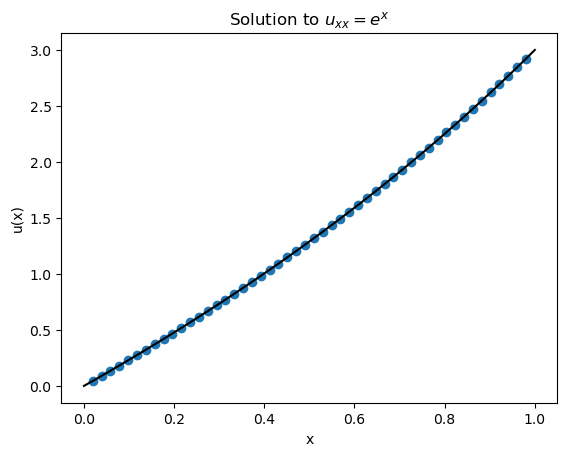

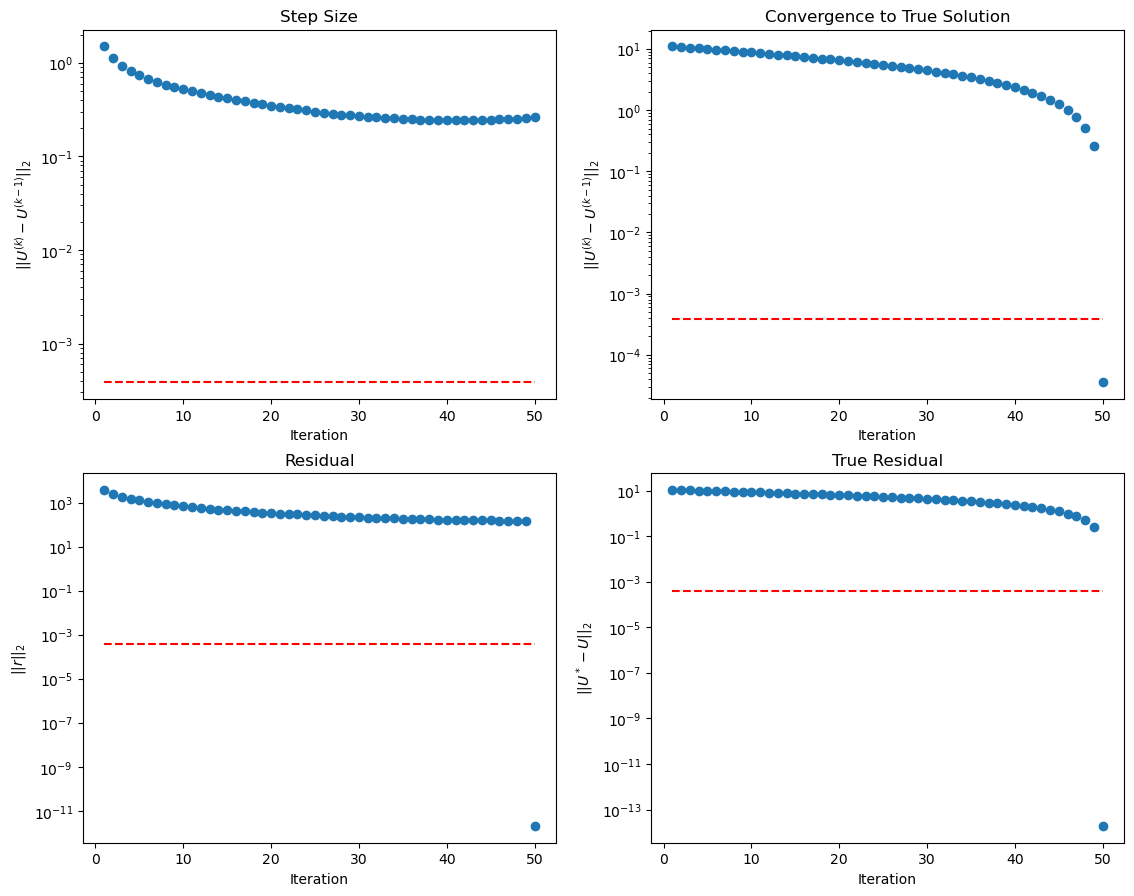

In [20]:
# Problem setup
a = 0.0                          # batas kiri domain
b = 1.0                          # batas kanan domain
alpha = 0.0                      # kondisi batas di x = a
beta = 3.0                       # kondisi batas di x = b
f = lambda x: numpy.exp(x)       # fungsi sumber u_xx = e^x
u_true = lambda x: (4.0 - numpy.exp(1.0)) * x - 1.0 + numpy.exp(x)  # solusi eksak

# Descretization
m = 50                           # jumlah titik interior
x_bc = numpy.linspace(a, b, m + 2)  # grid termasuk boundary
x = x_bc[1:-1]                   # titik interior
delta_x = (b - a) / (m + 1)      # jarak antar grid

# Construct matrix A
A = numpy.zeros((m, m))          # matriks sistem linear
diagonal = numpy.ones(m) / delta_x**2  # elemen diagonal utama

A += numpy.diag(diagonal * 2.0, 0)     # diagonal utama
A += numpy.diag(-diagonal[:-1], 1)     # diagonal atas
A += numpy.diag(-diagonal[:-1], -1)    # diagonal bawah

# Construct right hand side
b = -f(x)                        # vektor RHS
b[0] += alpha / delta_x**2       # kontribusi boundary kiri
b[-1] += beta / delta_x**2       # kontribusi boundary kanan

# Exact solution to system
U_true = numpy.linalg.solve(A, b)   # solusi eksak sistem linear (sebagai acuan)

# Algorithm parameters
MAX_ITERATIONS = 10000           # maksimum iterasi
tolerance = delta_x**2           # toleransi konvergensi

# Solve system
U = numpy.zeros(m)               # tebakan awal solusi
convergence_CG = numpy.zeros(MAX_ITERATIONS)   # error ke solusi eksak
step_size_CG = numpy.zeros(MAX_ITERATIONS)     # perubahan solusi
residual_norm = numpy.zeros(MAX_ITERATIONS)    # norma residual
system_convergence = numpy.zeros(MAX_ITERATIONS) # error ke solusi sistem
success = False                 # status konvergensi

r = -(b - numpy.dot(A, U))      # residual awal
p = -r                          # arah awal (search direction)
r_dot_r = numpy.dot(r, r)       # inner product residual

for k in range(MAX_ITERATIONS):
    # Convergence measures (not needed)
    U_old = U.copy()            # simpan solusi lama
    r_old = r.copy()            # simpan residual lama
    
    if numpy.linalg.norm(r, ord=2) < tolerance:  # cek konvergensi
        success = True
        break
    
    A_dot_p = numpy.dot(A, p)   # perkalian matriks A dengan arah p
    
    # Step length
    alpha =  r_dot_r / numpy.dot(p, A_dot_p)   # langkah optimal CG
    
    # Update solution and residual
    U += alpha * p             # update solusi
    r += alpha * A_dot_p       # update residual

    # Improvement of solution
    beta = numpy.dot(r, r) / r_dot_r   # parameter beta CG
    r_dot_r = numpy.dot(r, r)          # update nilai residual
    
    # Pick new direction for next iteration (if needed)
    p = beta * p - r           # arah baru (conjugate direction)

    # Convergence measures
    convergence_CG[k] = numpy.linalg.norm(u_true(x) - U, ord=2)   # error ke solusi eksak
    residual_norm[k] = numpy.linalg.norm(r, ord=2)                # norma residual
    step_size_CG[k] = numpy.linalg.norm(U - U_old, ord=2)         # perubahan solusi
    system_convergence[k] = numpy.linalg.norm(U_true - U, ord=2)  # error ke solusi sistem

if not success:
    print("Iteration failed to converge!")
    print(residual_norm[-10:])
    print(convergence_CG[-10:])
else:
    # Plot result
    fig = plt.figure()
    axes = fig.add_subplot(1, 1, 1)
    axes.plot(x, U, 'o', label="Computed")        # solusi numerik
    axes.plot(x_bc, u_true(x_bc), 'k', label="True")  # solusi eksak
    axes.set_title("Solution to $u_{xx} = e^x$")
    axes.set_xlabel("x")
    axes.set_ylabel("u(x)")

    fig = plt.figure()
    fig.set_figwidth(fig.get_figwidth() * 2.1)
    fig.set_figheight(fig.get_figheight() * 2.2)
    
    axes = fig.add_subplot(2, 2, 1)
    axes.semilogy(numpy.arange(1, k + 1), step_size_CG[:k], 'o')  # step size
    axes.semilogy(numpy.arange(1, k + 1), numpy.ones(k) * delta_x**2, 'r--')  # batas error
    axes.set_title("Step Size")
    axes.set_xlabel("Iteration")
    axes.set_ylabel("$||U^{(k)} - U^{(k-1)}||_2$")
    
    axes = fig.add_subplot(2, 2, 2)
    axes.semilogy(numpy.arange(1, k + 1), convergence_CG[:k], 'o')  # error ke solusi eksak
    axes.semilogy(numpy.arange(1, k + 1), numpy.ones(k) * delta_x**2, 'r--')
    axes.set_title("Convergence to True Solution")
    axes.set_xlabel("Iteration")
    axes.set_ylabel("$||U^{(k)} - U^{(k-1)}||_2$")

    axes = fig.add_subplot(2, 2, 3)
    axes.semilogy(numpy.arange(1, k + 1), residual_norm[:k], 'o')  # norma residual
    axes.semilogy(numpy.arange(1, k + 1), numpy.ones(k) * delta_x**2, 'r--')
    axes.set_title("Residual")
    axes.set_xlabel("Iteration")
    axes.set_ylabel("$||r||_2$")

    axes = fig.add_subplot(2, 2, 4)
    axes.semilogy(numpy.arange(1, k + 1), system_convergence[:k], 'o')  # error ke solusi sistem
    axes.semilogy(numpy.arange(1, k + 1), numpy.ones(k) * delta_x**2, 'r--')
    axes.set_title("True Residual")
    axes.set_xlabel("Iteration")
    axes.set_ylabel("$||U^* - U||_2$")
    
    print("Matrix condition number = %s" % (numpy.sqrt(numpy.linalg.norm(A) * numpy.linalg.norm(numpy.linalg.inv(A)))))
    # ukuran seberapa "baik" matriks (semakin besar → semakin sulit diselesaikan)
    
    plt.show()

Iteration count: 1
Iteration count: 2
Iteration count: 2


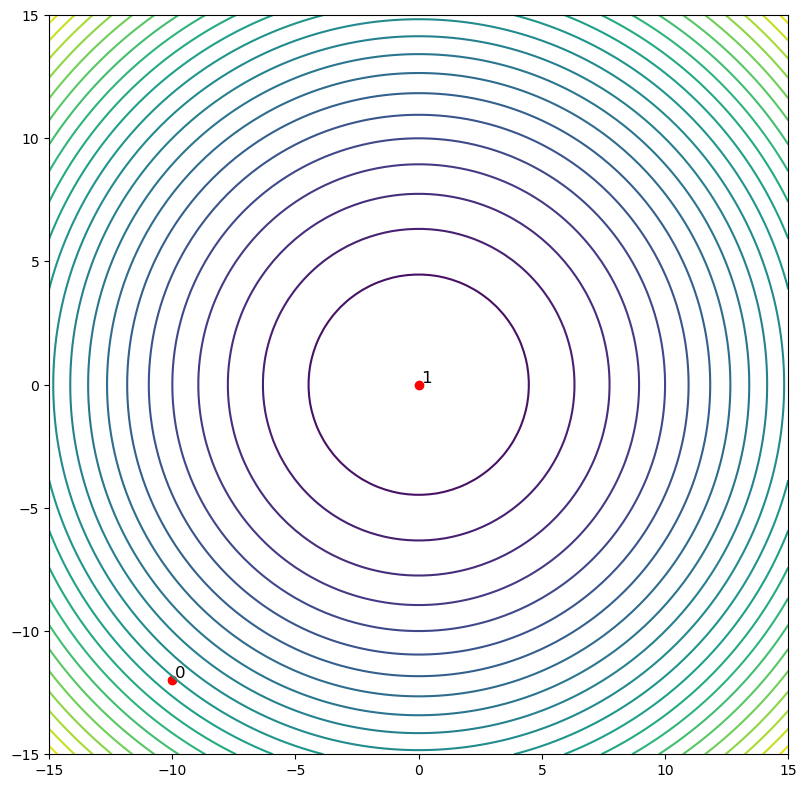

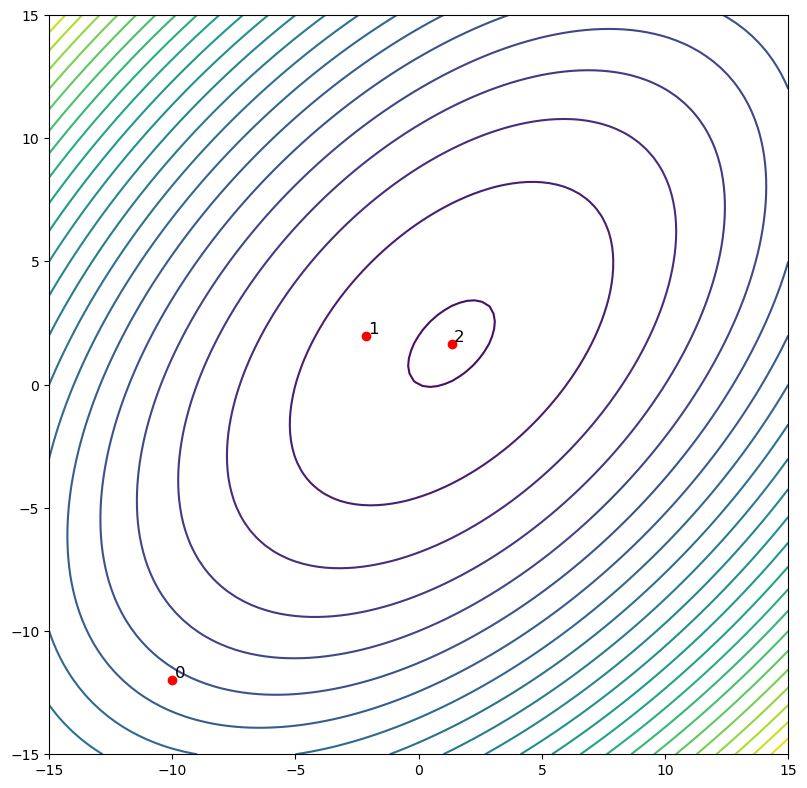

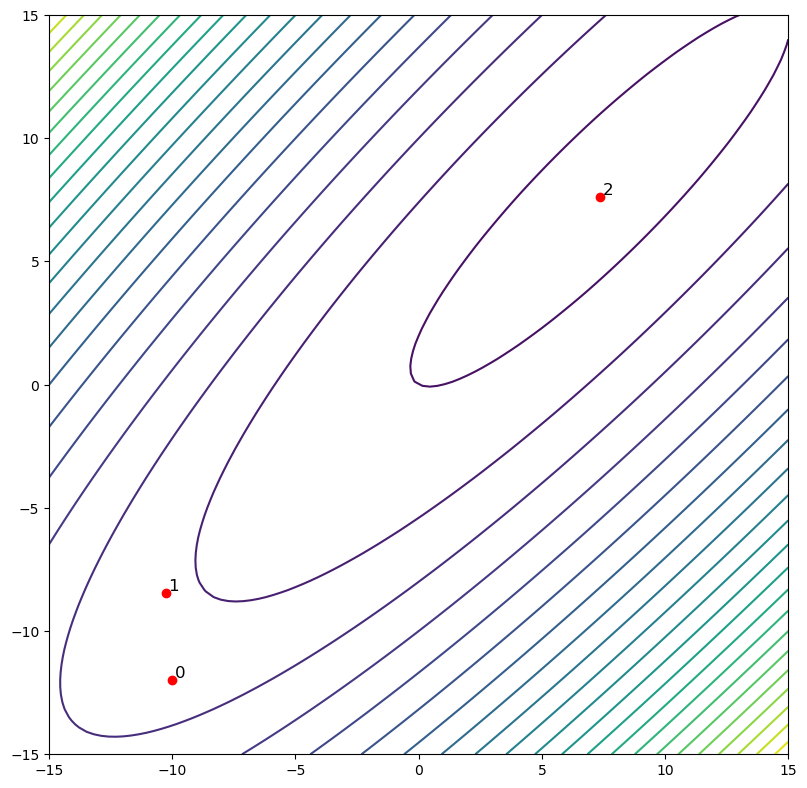

In [25]:
def CG(A, U, b, axes):
    MAX_ITERATIONS = A.shape[0] * 2   # maksimum iterasi (≈ 2n)
    tolerance = 1e-8                  # toleransi konvergensi
    success = False                  # penanda konvergensi
    iteration_locations = []         # simpan posisi tiap iterasi
    
    r = -(b - numpy.dot(A, U))       # residual awal
    p = -r                           # arah awal (conjugate direction pertama)
    r_dot_r = numpy.dot(r, r)        # inner product residual

    for k in range(MAX_ITERATIONS):
        axes.text(U[0] + 0.1, U[1] + 0.1, str(k), fontsize=12)  # label iterasi
        axes.plot(U[0], U[1], 'ro')     # plot titik iterasi
        iteration_locations.append(U)   # simpan posisi titik

        if numpy.linalg.norm(r, ord=2) < tolerance:  # cek konvergensi
            success = True
            break

        A_dot_p = numpy.dot(A, p)       # perkalian A dengan arah p

        # Step length
        alpha =  r_dot_r / numpy.dot(p, A_dot_p)  # langkah optimal CG

        # Update solution and residual
        U += alpha * p                 # update solusi
        r += alpha * A_dot_p           # update residual

        # Improvement of solution
        beta = numpy.dot(r, r) / r_dot_r   # parameter beta (CG)
        r_dot_r = numpy.dot(r, r)          # update nilai residual

        # Pick new direction for next iteration (if needed)
        p = beta * p - r               # arah baru (conjugate direction)
    
    if success:
        return k, iteration_locations  # k = jumlah iterasi
    else:
        raise Exception("Iteration did not converge.")

phi = lambda X, Y, A: 0.5 * (A[0, 0] * X**2 + A[0, 1] * X * Y + A[1, 0] * X * Y + A[1, 1] * Y**2) - X * f[0] - Y * f[1]
# fungsi kuadratik (energi) yang diminimalkan

x = numpy.linspace(-15, 15, 100)   # grid x
y = numpy.linspace(-15, 15, 100)   # grid y
X, Y = numpy.meshgrid(x, y)        # meshgrid untuk contour

fig = plt.figure()
fig.set_figwidth(fig.get_figwidth() * 2)    # perbesar lebar figure
fig.set_figheight(fig.get_figheight() * 2)  # perbesar tinggi figure
axes = fig.add_subplot(1, 1, 1, aspect='equal')  # subplot

A = numpy.identity(2)              # matriks identitas
f = numpy.array([0.0, 0.0])        # RHS nol
k, iteration_locations = CG(A, numpy.array([-10.0, -12.0]), f, axes)
# jalankan CG dari titik awal

axes.contour(X, Y, phi(X, Y, A), 25)  # contour fungsi
print("Iteration count: %s" % k)      # tampilkan jumlah iterasi

fig = plt.figure()
fig.set_figwidth(fig.get_figwidth() * 2)
fig.set_figheight(fig.get_figheight() * 2)
axes = fig.add_subplot(1, 1, 1, aspect='equal')

A = numpy.array([[2, -1], [-1, 2]])   # matriks SPD (lebih realistis)
f = numpy.array([1.0, 2.0])           # RHS
k, iteration_locations = CG(A, numpy.array([-10.0, -12.0]), f, axes)

axes.contour(X, Y, phi(X, Y, A), 25)  # contour
print("Iteration count: %s" % k)

fig = plt.figure()
fig.set_figwidth(fig.get_figwidth() * 2)
fig.set_figheight(fig.get_figheight() * 2)
axes = fig.add_subplot(1, 1, 1, aspect='equal')

A = numpy.array([[2, -1.8], [-1.8, 2]])  # hampir singular (ill-conditioned)
f = numpy.array([1.0, 2.0])
k, iteration_locations = CG(A, numpy.array([-10.0, -12.0]), f, axes)

axes.contour(X, Y, phi(X, Y, A), 25)  # contour
print("Iteration count: %s" % k)

Algoritme gradien konjugasi memerlukan operasi $\mathcal{O}(m^2)$ dan secara teori $m$ melakukan iterasi untuk mencapai solusi yang tepat.  Namun dalam praktiknya, hal ini umumnya dapat menyatu lebih cepat, terutama bila menggunakan pengkondisian awal.  Hal ini terutama berlaku untuk stensil Laplacian 5 titik dua dimensi yang telah kita lihat.

### Subruang Krylov

Kita dapat mengatakan banyak hal tentang himpunan vektor $p^{(k)}$ yang merentang ruang, himpunan level $\phi$ kita dimulai dengan teorema berikut.

**Teorema** Vektor yang dihasilkan dalam algoritma CG memiliki properti berikut, asalkan $r^{(k)} \neq 0$ :
1. $p^{(k)}$ adalah $A$ -konjugasi ke semua arah pencarian sebelumnya
1. Sisa $r^{(k)}$ ortogonal terhadap semua sisa $(r^{(k)})^T r_j = 0 \quad \forall j=0,1,\ldots$ sebelumnya 
1. Tiga subruang $\mathbb R^m$ berikut ini identik
 $$\begin{aligned}
    &\text{span} (p^{(0)}, p^{(1)}, \ldots, p^{(k-1)}) \\
    &\text{span} (r^{(0)}, A r^{(0)}, A^2 r^{(0)}, \ldots, A^{k-1} r^{(0)}) \\
    &\text{span} (A e^{(0)}, A^2 e^{(0)}, A^3 e^{(0)}, \ldots, A^{k} e^{(0)})
\end{aligned}$$ 

Subruang $\mathcal{K}_k = \text{span} (r^{(0)}, A r^{(0)}, A^2 r^{(0)}, \ldots, A^{k-1} r^{(0)})$ yang direntangkan oleh vektor $r^{(0)}$ dan pangkat $k-1$ pertama dari $A$ ke $r^{(0)}$ disebut *ruang Krylov* berdimensi $k$ yang diasosiasikan dengan $r^{(0)}$ .

### Proyeksi

Pembaruan baru $u^{(k)}$ dibentuk dengan menambahkan kelipatan $p^{(j)}$ ke tebakan awal $u^{(0)}$ dan karenanya terletak pada subruang $u_0 + \mathcal{K}_k$ .  Cara lain untuk menulis ini adalah dengan mengatakan $u^{(k)} - u^{(0)} \in \mathcal{K}_k$ .  Perhatikan kesamaan antara ini dan diskusi proyeksi kita.

### Konvergensi Gradien Konjugasi

Kita sekarang beralih ke konvergensi CG dan menurunkan perkiraan tentang ukuran kesalahan pada $k$ tertentu dan tingkat konvergensi.

Pertama tentukan $A$ -norm s.t.
 $$
    ||e||_A = \sqrt{e^T A e}
$$ 
mengandalkan fakta bahwa $A$ adalah SPD.

Hal ini mengarah ke
 $$\begin{aligned}
    ||e||^2_A &= (u - u^\ast)^T A (u - u^\ast) \\
    &=u^T A u - 2 u^T A u^\ast + (u^\ast)^T A u^\ast \\
    &= 2 \phi(u) + (u^\ast)^T A u^\ast
\end{aligned}$$ 

Mengingat $(u^\ast)^T A u^\ast$ adalah konstanta yang meminimalkan kesalahan $||e||_A$ setara dengan meminimalkan $\phi(u)$ .

Kita tahu kita dapat memperluas $u^{(k)}$ di subpsace $u_0 + \mathcal{K}_k$ sehingga
 $$
    u^{(k)} = u^{(0)} + \alpha^{(0)} p^{(0)} + \alpha^{(1)} p^{(1)} + \cdots + \alpha^{(k-1)} p^{(k-1)}
$$ 
dan mengurangkan $u^\ast$ kita temukan
 $$
    u^{(k)} - u^\ast = e^{(k)} = e^{(0)} + \alpha^{(0)} p^{(0)} + \alpha^{(1)} p^{(1)} + \cdots + \alpha^{(k-1)} p^{(k-1)}
$$ 
yang menghubungkan $e^{(k)}$ dan $e^{(0)}$ dan menyiratkan bahwa $e^{(k)} - e^{(0)} \in \mathcal{K}_k$ .

Dengan teorema kita di atas, kita juga mengetahui hal itu
 $$
    e^{(k)} - e^{(0)} \in \text{span} (A e^{(0)}, A^2 e^{(0)}, A^3 e^{(0)}, \ldots, A^{k} e^{(0)})
$$ 
jadi itu
 $$
    e^{(k)} = e^{(0)} + c_1 A e^{(0)} + c_2 A^2 e^{(0)} + \cdots + c_k A^k e^{(0)}
$$ 
di mana $c_j$ adalah beberapa koefisien (ditemukan dengan mengambil proyeksi $e^{(k)}$ ke dalam rentang).

Hal ini kemudian mengarah pada
 $$
    e^{(k)} = P_k(A) e^{(0)}
$$ 
dimana
 $$
    P_k(A) = I + c_1 A + c_2 A^2 + \cdots + c_k A^k.
$$ 
Perhatikan bahwa $P_k(A)$ adalah polinomial di $A$ .  Kita dapat menghubungkannya dengan polinomial skalar dengan membiarkan
 $$
    P_k(x) = 1 + c_1 x + c_2 x^2 + \cdots +c_k x^k
$$ 
sehingga $P_k \in \mathcal{P}_k$ di mana $\mathcal{P}_k$ adalah polinomial dengan derajat paling banyak $k$ dan $P(0) = 1$ .

CG secara implisit membuat polinomial $P_k$ dan memecahkan masalah minimalisasi terkait
 $$
    \min_{P \in \mathcal{P}_k} ||P(A) e^{(0)}||_A.
$$

#### Apa yang dimaksud dengan polinomial matriks?

Jika kita mengetahui bahwa matriks kita dapat didiagonalisasi, kita dapat menulis diagonalisasi ini sebagai
 $$
    A = V \Lambda V^{-1}.
$$

Jika kita mengambil kekuatan $A$ maka kita akan menemukannya
 $$
    A^k = (V \Lambda V^{-1})^k = V \Lambda V^{-1} V \Lambda V^{-1} \cdots V \Lambda V^{-1} = V \Lambda^k V^{-1}.
$$

Polinomial pada $A$ kemudian dapat ditulis sebagai
 $$
    P_k(A) = V P_k(\Lambda) V^{-1}
$$ 
jadi itu
 $$
    P_k(\Lambda) = \begin{bmatrix}
        P_k(\lambda_1) \\
        & P_k(\lambda_2) \\
        & & P_k(\lambda_3) \\
        & & & \ddots \\
        & & & & P_k(\lambda_m)
    \end{bmatrix}.
$$

Sekarang kembali ke ekspresi kita untuk kesalahan yang kita miliki
 $$
    e^{(k)} = P_k(A) e^{(0)}.
$$ 
Jika polinomial $P_k(A)$ memiliki akar pada setiap $\lambda_k$ maka $P_k(\Lambda)$ adalah matriks nol dan ekspresi kesalahan di atas membawa kita pada kesimpulan bahwa $e^{(k)} = 0$ .  Jika nilai eigen diulang (katakanlah kita mempunyai nilai eigen unik $n$, ini dikenal sebagai multiplisitas geometris) maka kita dapat mengatakan bahwa ada lagi polinomial $P_n \in \mathcal{P}_n$ yang juga memiliki akar-akar ini dan kita harapkan $e^{(n)} = 0$ , kita konvergen lebih cepat daripada dimensi $A$ !

Katakanlah kita ingin mengetahui seberapa besar kesalahannya sebelum iterasi yang menjamin konvergensi?  Kami kemudian ingin mengetahui bagaimana perilaku $||e^{(0)}||_A$.  Ternyata untuk $P \in \mathcal{P}$ apa pun yang kita miliki
 $$
    \frac{||P(A)e^{(0)}||_A}{||e^{(0)}||_A} \leq \max_{1 \leq j \leq m} |P(\lambda_j)|.
$$ 
Kita kemudian perlu menemukan satu polinomial $\hat{P_k} \in \mathcal{P}_k$ sehingga kita dapat memperoleh batasan yang berguna pada $||e^{(k)}||_A / ||e^{(0)}||_A$ .

Versi polinomial Chebyshev yang digeser dan diskalakan secara mengejutkan, $T_k(x)$, akan berfungsi untuk ini!  Pengaturan
 $$
    \hat{P_k}(x) = \frac{T_k\left(\frac{\lambda_m + \lambda_1 - 2x}{\lambda_m - \lambda_1} \right )}{T_k\left(\frac{\lambda_m + \lambda_1}{\lambda_m - \lambda_1}\right ) }
$$ 

dan menghitung 
 $$
    \max_{1\leq j \leq m} \left |\hat{P_k}(\lambda_j) \right|.
$$

Dengan beberapa analisis (lihat LeVeque untuk derivasi selengkapnya) kami dapat menunjukkan hal itu 
 $$
    T_k(x) = \frac{1}{2} \left[ \left ( \frac{\sqrt{\kappa} + 1}{\sqrt{\kappa} - 1} \right)^k + \left ( \frac{\sqrt{\kappa} - 1}{\sqrt{\kappa} + 1} \right)^k \right ]
$$ 
dan
 $$
    \frac{||P(A) e^{(0)}||_A}{||e^{(0)}||_A} \leq 2 \left[ \left ( \frac{\sqrt{\kappa} + 1}{\sqrt{\kappa} - 1} \right)^k + \left ( \frac{\sqrt{\kappa} - 1}{\sqrt{\kappa} + 1} \right)^k \right ]^{-1} \leq 2 \left ( \frac{\sqrt{\kappa} - 1}{\sqrt{\kappa} + 1} \right)^k
$$ 
dimana $\kappa$ adalah bilangan kondisi matriks.

Jika bilangan kondisi matriks $\kappa$ besar, kita juga dapat menyederhanakan batasannya
 $$
    2 \left ( \frac{\sqrt{\kappa} - 1}{\sqrt{\kappa} + 1} \right)^k \approx 2 \left ( 1 - \frac{2}{\sqrt{\kappa}} \right)^k \approx 2 e^{-2 k / \sqrt{\kappa}}.
$$ 
Ini menyiratkan bahwa jumlah iterasi yang diharapkan $k$ untuk mencapai toleransi yang diinginkan adalah $k = \mathcal{O}\left(\sqrt{\kappa}\right)$ .

### Pengkondisian awal

Salah satu cara untuk mengatasi kesulitan metode jenis ini akibat distorsi elips (dan akibatnya pengkondisian matriks) adalah dengan mengkondisikan matriks terlebih dahulu.  Ide dasarnya adalah kita mengambil masalah awal kita $A u = f$ dan menyelesaikannya
 $$
    M^{-1} A u = M^{-1} f.
$$

Perhatikan bahwa karena kita perlu mencari invers dari $M$ , matriks ini seharusnya bagus.  Beberapa contoh ilustratif dapat membantu mengilustrasikan mengapa ini merupakan ide yang bagus:

 - Jika $M = A$ maka pada dasarnya kita telah menyelesaikan masalah kita meskipun itu tidak banyak membantu kita
 - Jika $M = \text{diag}(A)$ , maka $M^{-1}$ mudah dihitung dan ternyata untuk beberapa permasalahan hal ini dapat menurunkan angka kondisi $M^{-1} A$ secara signifikan.  Namun perlu dicatat bahwa ini sebenarnya tidak membantu dalam kasus masalah Poisson.
 - Jika $M$ didasarkan pada metode iteratif lain yang digunakan pada $A$ , misalnya Gauss-Seidel, ini bisa menjadi prakondisi penggunaan umum yang efektif untuk banyak masalah.

 Jadi pertanyaan selanjutnya adalah bagaimana memilih prakondisi.  Hal ini biasanya sangat spesifik terhadap permasalahan dan sejumlah makalah menyarankan strategi untuk permasalahan tertentu.  Secara umum kita ingin memindahkan nilai eigen sehingga matriks tidak memiliki kondisi yang buruk.  Menggabungkan prakondisi dengan CG menghasilkan metode PCG yang populer.

## Algoritma Generalized Minimum Residual (GMRES).

GMRES adalah salah satu pendekatan untuk memecahkan masalah ini bagi kami.  Karena kita tidak dapat lagi bergantung pada struktur masalah minimisasi skalar yang terkait, kita akan meminimalkan sisa pada subruang yang sama dengan yang kita miliki sebelum menggunakan pendekatan kuadrat terkecil.

Dalam iterasi $k$, GMRES memecahkan masalah kuadrat terkecil dalam subruang tertentu dari masalah penuh.  Dalam hal ini kita akan menggunakan spasi yang kita lihat sebelumnya, $u_0 + \mathcal{\kappa}_k$ , dimana $\mathcal{\kappa}$ didefinisikan sebagai
 $$
    \kappa_k = \text{span} (r^{(0)}, A r^{(0)}, A^2 r^{(0)}, \ldots, A^{k-1} r^{(0)}).
$$

Untuk melakukan hal ini kita membuat matriks $Q$ yang dalam kolomnya memuat sekumpulan vektor ortonormal yang merentang ruang $\kappa_k$ .  Karena ini berulang setiap kali kita menaikkan $k$, kita hanya perlu mencari satu vektor tambahan agar $Q$ menjangkau ruang berikutnya.

Dimulai dengan iterasi ke $k$ yang kita miliki
 $$
    Q = [q_1 q_2 q_3 \cdots~q_k] \in \mathbb R^{m \times k}.
$$ 
Pilih sebuah vektor $v_j \notin \kappa_k$ dan gunakan Gram-Shmidt (atau yang serupa) untuk melakukan ortogonalisasi vektor ini ke semua $q_i$ lainnya.

Apa yang harus kita pilih untuk $v_j$?

Ada beberapa pilihan yang buruk seperti $v_k = A^k r^{(k)}$ (ini berfungsi tetapi menghasilkan nilai tunggal yang sangat kecil).

Sebaliknya kita akan memilih $v_k = A q_k$ .  Sebenarnya kita sedang membangun faktorisasi matriks $A$ .  Proses ini disebut *proses Arnoldi*.

### Proses Arnoldi

Proses Arnoldi membangun basis ortogonal dari subruang Krylov $\mathcal{K}_m$ .  Kita dapat menggunakan salah satu algoritma untuk menemukan ortogonalisasi (misalnya Gram-Schmidt).  Intinya maka kita memiliki prosedur berikut

Inisialisasi proses dengan vektor $v_0$ dengan $||v_0|| = 1$ .  Sekarang ulangi langkah-langkah berikut:
1. $w_k = A v_{k-1}$ 
2. Ortogonalisasikan vektor $w_j$ terhadap semua $v_j \quad j < k$ sebelumnya 
3. Berhenti ketika $w_j$ hilang.

Proses ini memiliki efek praktis dalam menciptakan transformasi berikut
 $$
    A V_m = V_m H_m
$$ 
dimana $V_m$ adalah matriks $m \times m$ dengan kolom vektor yang dihitung $v_j$ dan $H_m$ adalah $(m + 1) \times m$ Matriks Hessenberg yang entri bukan nolnya adalah $h_{ij}$ yang didefinisikan sebagai $h_{ij} = A v_j \cdot v_i$ dan $h_{j+1,j} = ||w_j||_2$ dengan penghapusan baris terakhir.  Ini menggambarkan dengan tepat proses ortogonalisasi.

Sekarang bagaimana kita menerapkannya?  Diberikan tebakan awal $x^{(0)}$ pertimbangkan metode proyeksi ortogonal dimana
 $$
    \mathcal{L} = \mathcal{K} = \mathcal{K}_m(A, r^{(0)})
$$ 
di mana subruang Krylov berada
 $$
    \mathcal{K}_m(A, r^{(0)}) = \text{span}\{r^{(0)}, A r^{(0)}, A^2 r^{(0)}, \ldots,A^{m-1} r^{(0)} \}.
$$

Biarkan $v_1 = r^{(0)} / || r^{(0)} ||_2$ dan terapkan metode Arnoldi yang akan kita miliki
 $$
    V^T_m A V_m = H_m
$$ 
yang juga menyiratkan hal itu
 $$
    V^T_m r^{(0)} = V^T_m (\beta v_1) = \beta e_1
$$ 
dimana $\beta = ||r^{(0)}||_2$ .  Kami kemudian dapat menemukannya
 $$
    x_m = x^{(0)} + V_m y_m \\
    y_m = H^{-1}_m (\beta e_1)
$$

Algoritme ini setara dengan Conjugate Gradient jika matriksnya adalah SPD.  

Perhatikan juga bahwa jika matriksnya simetris, matriks Hessenberg $H$ juga simetris yang menyiratkan bahwa matriks tersebut berbentuk tri-diagonal yang sangat menyederhanakan hasil umum kita.



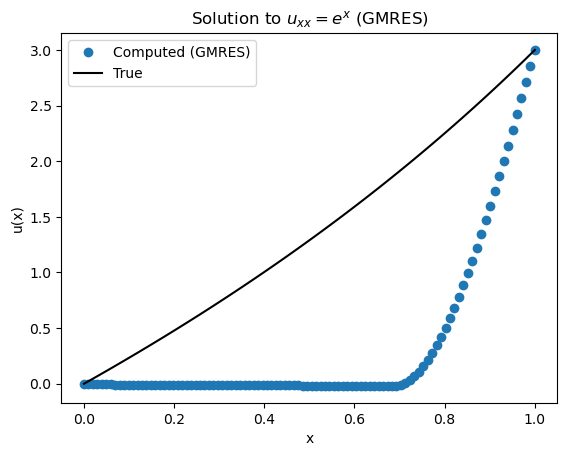

In [29]:
import numpy
import matplotlib.pyplot as plt

# ===============================
# ARNOLDI (diperbaiki → return V dan H)
# ===============================
def arnoldi(A, b, m):
    n = b.shape[0]                      # ukuran sistem
    V = numpy.zeros((n, m + 1))         # basis Krylov (kolom = vektor basis)
    H = numpy.zeros((m + 1, m))         # matriks Hessenberg
    
    beta = numpy.linalg.norm(b)         # norma awal residual
    V[:, 0] = b / beta                  # vektor awal dinormalisasi
    
    for j in range(m):
        w = numpy.dot(A, V[:, j])       # proyeksi ke ruang Krylov
        
        for i in range(j + 1):
            H[i, j] = numpy.dot(V[:, i], w)  # koefisien proyeksi
            w = w - H[i, j] * V[:, i]        # ortogonalisasi (Gram-Schmidt)
        
        H[j + 1, j] = numpy.linalg.norm(w)   # norma sisa
        
        if H[j + 1, j] != 0 and j != m - 1:
            V[:, j + 1] = w / H[j + 1, j]    # basis berikutnya (normalisasi)
    
    return V, H, beta                # return basis Krylov, Hessenberg, dan beta


# ===============================
# PROBLEM SETUP
# ===============================
a = 0.0                              # batas kiri domain
b = 1.0                              # batas kanan domain
alpha = 0.0                          # boundary kiri
beta_bc = 3.0                        # boundary kanan

f = lambda x: numpy.exp(x)           # fungsi sumber
u_true = lambda x: (4.0 - numpy.exp(1.0)) * x - 1.0 + numpy.exp(x)  # solusi eksak

# ===============================
# DISCRETIZATION
# ===============================
m = 100                              # jumlah titik interior
x_bc = numpy.linspace(a, b, m + 2)   # grid lengkap
x = x_bc[1:-1]                       # titik interior
delta_x = (b - a) / (m + 1)          # jarak grid

# ===============================
# MATRIX A
# ===============================
A = numpy.zeros((m, m))              # matriks sistem linear
diag = numpy.ones(m) / delta_x**2    # nilai diagonal

A += numpy.diag(2 * diag)            # diagonal utama
A += numpy.diag(-diag[:-1], 1)       # diagonal atas
A += numpy.diag(-diag[:-1], -1)      # diagonal bawah

# ===============================
# RHS
# ===============================
b_vec = -f(x)                        # vektor RHS
b_vec[0] += alpha / delta_x**2       # kontribusi boundary kiri
b_vec[-1] += beta_bc / delta_x**2    # kontribusi boundary kanan

# ===============================
# GMRES (via Arnoldi)
# ===============================
U0 = numpy.zeros(m)                  # tebakan awal solusi
r0 = b_vec - numpy.dot(A, U0)        # residual awal

k_dim = 30                           # dimensi subspace Krylov (lebih kecil dari m)
V, H, beta0 = arnoldi(A, r0, k_dim)  # bangun basis Krylov dengan Arnoldi

# least squares: min ||beta e1 - H y||
e1 = numpy.zeros(k_dim + 1)          # vektor basis pertama
e1[0] = beta0                        # hanya elemen pertama bernilai beta

y, _, _, _ = numpy.linalg.lstsq(H, e1, rcond=None)  
# menyelesaikan least squares (inti GMRES)

# update solusi
U_inner = U0 + numpy.dot(V[:, :k_dim], y)  
# solusi hasil proyeksi ke subspace Krylov

# ===============================
# TAMBAHKAN BOUNDARY
# ===============================
U = numpy.zeros(m + 2)               # solusi lengkap (termasuk boundary)
U[0] = alpha                         # boundary kiri
U[-1] = beta_bc                      # boundary kanan
U[1:-1] = U_inner                    # isi bagian interior

# ===============================
# PLOT
# ===============================
plt.figure()
plt.plot(x_bc, U, 'o', label="Computed (GMRES)")  # solusi numerik
plt.plot(x_bc, u_true(x_bc), 'k', label="True")   # solusi eksak
plt.title("Solution to $u_{xx} = e^x$ (GMRES)")
plt.xlabel("x")
plt.ylabel("u(x)")
plt.legend()
plt.show()

## Multigrid

### Jacobi Ditinjau Kembali

Perhatikan masalah Poisson dengan
 $$
    f(x) = -20 + \frac{1}{2}\left ( \phi''(x) \cos \phi(x) -  (\phi'(x))^2 \sin \phi(x) \right )
$$ 
dengan
 $$
    \phi = 20 \pi x^3,
$$ 
dan kondisi batas $u(0) = 1$ dan $u(1) = 3$ .

Mengintegrasikan dua kali kita dapat menemukan bahwa solusi dari masalah ini adalah
 $$
    u(x) = 1 + 12 x - 10 x^3 + \frac{1}{2} \sin \phi(x).
$$ 

Mendiskritisasi masalah ini dengan cara standar dengan perbedaan hingga terpusat orde kedua mengarah ke kode berikut

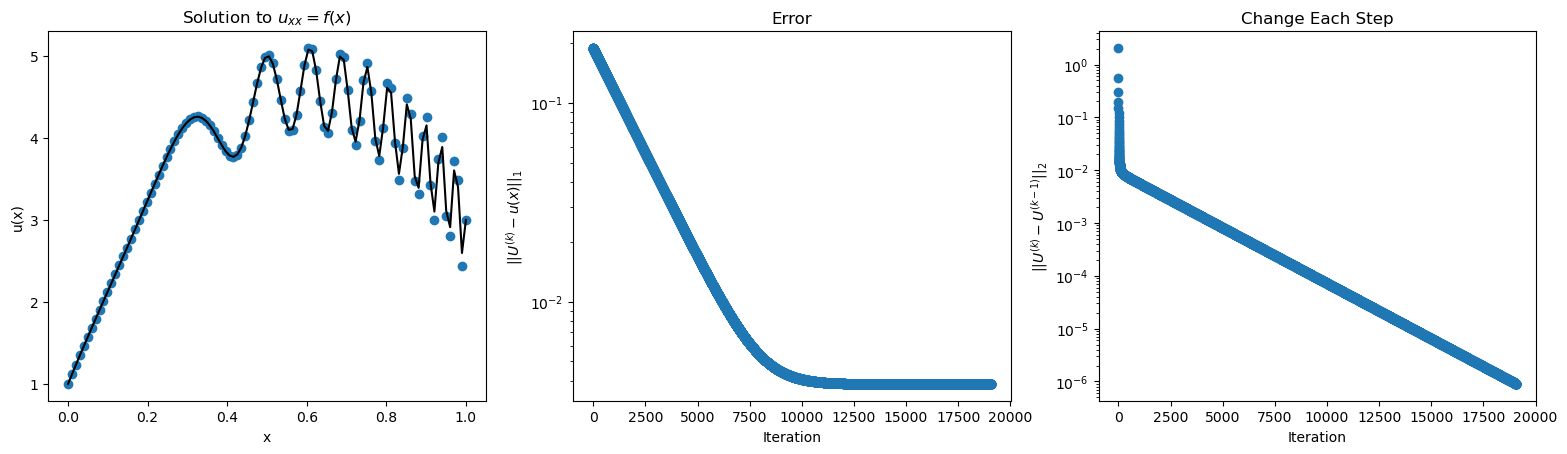

In [33]:
def jacobi_update(x, U, f, delta_x):
    """Update U with a single Jacobi iteration"""
    U_new = U.copy()  # salin solusi lama (Jacobi pakai nilai lama semua)
    for i in range(1, x.shape[0] - 1):  # loop titik interior
        U_new[i] = 0.5 * (U[i+1] + U[i-1]) - f(x[i]) * delta_x**2 / 2.0  
        # rumus finite difference untuk u_xx = f(x)
    step_size = numpy.linalg.norm(U_new - U, ord=2)  # perubahan solusi
    del(U)  # hapus referensi lama (opsional)
    return U_new, step_size  # kembalikan solusi baru + perubahan


# Problem setup
a = 0.0                          # batas kiri domain
b = 1.0                          # batas kanan domain
alpha = 1.0                      # boundary kiri
beta = 3.0                       # boundary kanan

phi = lambda x: 20.0 * numpy.pi * x**3          # fungsi bantu
phi_prime = lambda x: 60.0 * numpy.pi * x**2    # turunan pertama
phi_dbl_prime = lambda x: 120.0 * numpy.pi * x  # turunan kedua

f = lambda x: -20.0 + 0.5 * (phi_dbl_prime(x) * numpy.cos(phi(x)) - (phi_prime(x))**2 * numpy.sin(phi(x)))
# fungsi sumber (dibuat agar punya solusi eksak tertentu)

u_true = lambda x: 1.0 + 12.0 * x - 10.0 * x**2 + 0.5 * numpy.sin(phi(x))
# solusi eksak (untuk validasi)

# Descretization
m = 100                                # jumlah titik interior
x_bc = numpy.linspace(a, b, m + 2)     # grid lengkap
x = x_bc[1:-1]                         # titik interior
delta_x = (b - a) / (m + 1)            # jarak grid

# Expected iterations needed
iterations_J = int(2.0 * numpy.log(delta_x) / numpy.log(1.0 - 0.5 * numpy.pi**2 * delta_x**2))
# estimasi jumlah iterasi Jacobi
# iterations_J = 100

# Solve system
# Initial guess for iterations
U = 1.0 + 2.0 * x_bc      # tebakan awal (linear)
U[0] = alpha              # set boundary kiri
U[-1] = beta              # set boundary kanan

convergence_J = numpy.zeros(iterations_J)  # simpan error
step_size = numpy.zeros(iterations_J)      # simpan perubahan tiap iterasi

for k in range(iterations_J):
    U, step_size[k] = jacobi_update(x_bc, U, f, delta_x)  
    # lakukan 1 iterasi Jacobi

    convergence_J[k] = numpy.linalg.norm(delta_x * (u_true(x_bc) - U), ord=2)  
    # error terhadap solusi eksak

# Plot result
fig = plt.figure()
fig.set_figwidth(fig.get_figwidth() * 3)  # perbesar figure

axes = fig.add_subplot(1, 3, 1)
axes.plot(x_bc, U, 'o', label="Computed")        # solusi numerik
axes.plot(x_bc, u_true(x_bc), 'k', label="True") # solusi eksak
axes.set_title("Solution to $u_{xx} = f(x)$")
axes.set_xlabel("x")
axes.set_ylabel("u(x)")

axes = fig.add_subplot(1, 3, 2)
axes.semilogy(list(range(iterations_J)), convergence_J, 'o')  
# plot error (log scale)
axes.set_title("Error")
axes.set_xlabel("Iteration")
axes.set_ylabel("$||U^{(k)} - u(x)||_1$")

axes = fig.add_subplot(1, 3, 3)
axes.semilogy(list(range(iterations_J)), step_size, 'o')  
# perubahan tiap iterasi
axes.set_title("Change Each Step")
axes.set_xlabel("Iteration")
axes.set_ylabel("$||U^{(k)} - U^{(k-1)}||_2$")

plt.show()

Kami akhirnya bertemu meskipun kami melihat bahwa ada batas bawah efektivitas iterasi Jacobi.  Kami juga kembali mengamati konvergensi yang sangat lambat seperti yang kami perkirakan.  Bagaimana jika kita masih bisa memanfaatkan Jacobi?

0.004787033973514997
0.002976859571820206
0.0025489705386463946
0.0023700892780919966
0.002265923030068573


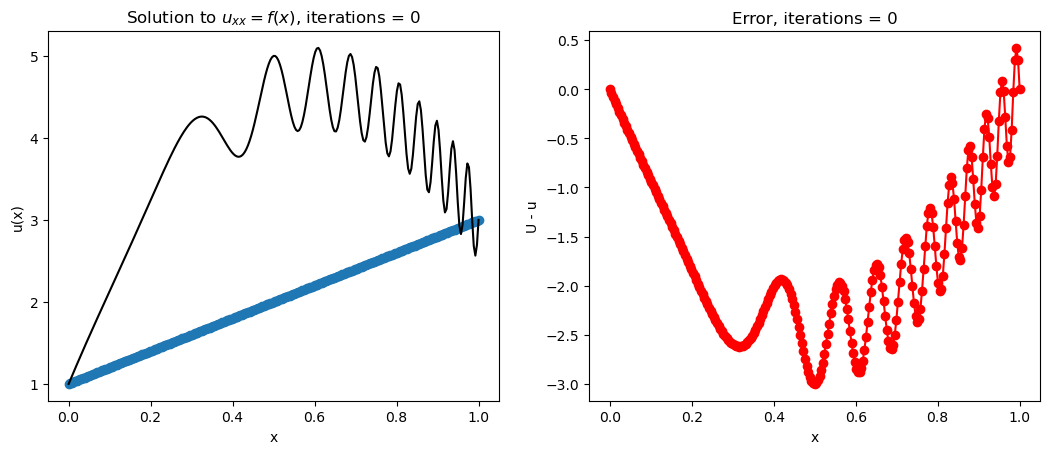

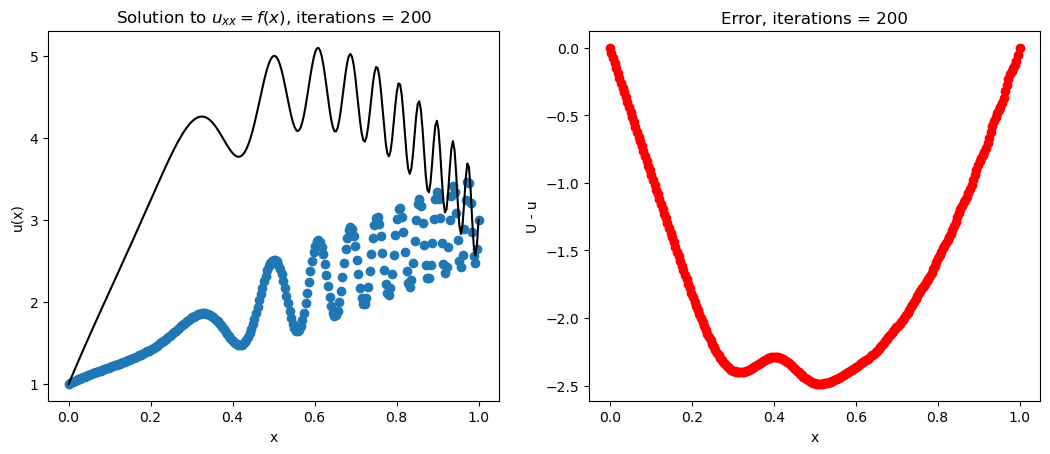

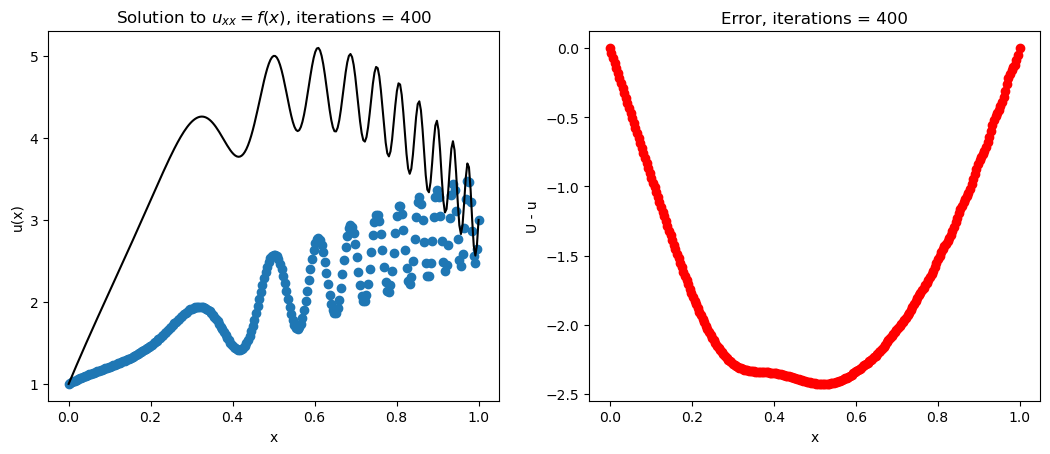

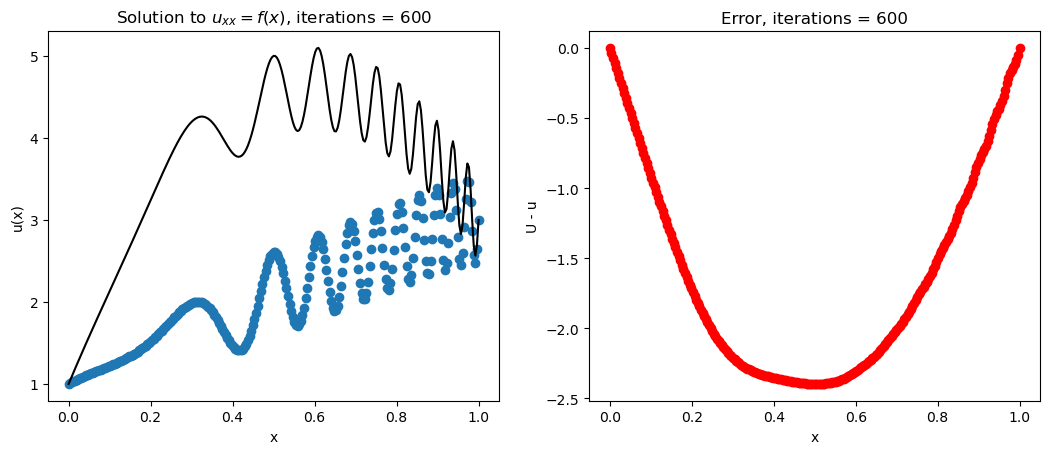

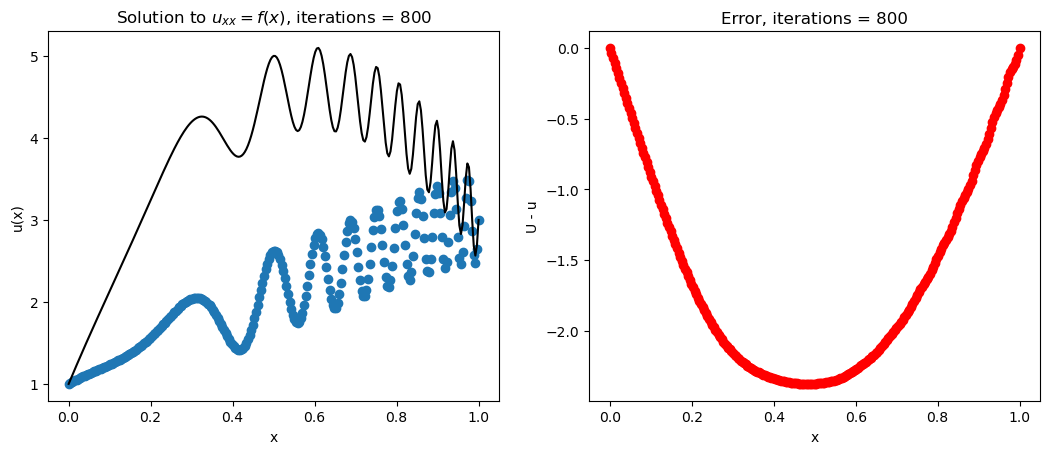

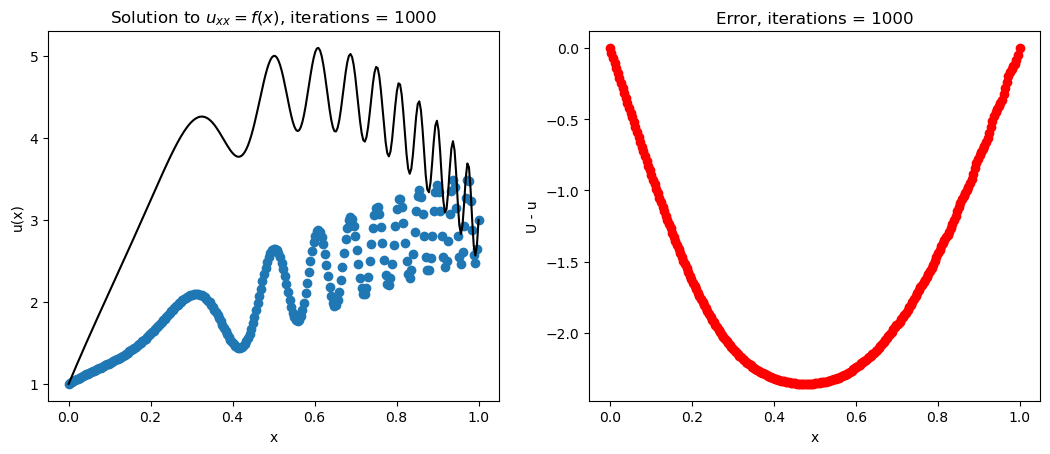

In [34]:
# Problem setup
a = 0.0                              # batas kiri domain
b = 1.0                              # batas kanan domain
alpha = 1.0                          # boundary kiri
beta = 3.0                           # boundary kanan

phi = lambda x: 20.0 * numpy.pi * x**3          # fungsi bantu
phi_prime = lambda x: 60.0 * numpy.pi * x**2    # turunan pertama
phi_dbl_prime = lambda x: 120.0 * numpy.pi * x  # turunan kedua

f = lambda x: -20.0 + 0.5 * (phi_dbl_prime(x) * numpy.cos(phi(x)) - (phi_prime(x))**2 * numpy.sin(phi(x)))
# fungsi sumber u_xx = f(x)

u_true = lambda x: 1.0 + 12.0 * x - 10.0 * x**2 + 0.5 * numpy.sin(phi(x))
# solusi eksak (untuk validasi)

# Descretization
m = 255                                # jumlah titik interior (lebih halus)
x_bc = numpy.linspace(a, b, m + 2)     # grid lengkap
x = x_bc[1:-1]                         # titik interior
delta_x = (b - a) / (m + 1)            # jarak grid

U = 1.0 + 2.0 * x_bc                   # tebakan awal (linear)
U[0] = alpha                           # set boundary kiri
U[-1] = beta                           # set boundary kanan

num_steps = 1000                       # jumlah iterasi Jacobi
plot_frequency = 200                   # tampilkan plot tiap 200 iterasi

# Plot initial error
fig = plt.figure()
fig.set_figwidth(fig.get_figwidth() * 2)  # perbesar figure

axes = fig.add_subplot(1, 2, 1)
axes.plot(x_bc, U, 'o', label="Computed")        # solusi awal
axes.plot(x_bc, u_true(x_bc), 'k', label="True") # solusi eksak
axes.set_title("Solution to $u_{xx} = f(x)$, iterations = %s" % 0)
axes.set_xlabel("x")
axes.set_ylabel("u(x)")

axes = fig.add_subplot(1, 2, 2)
axes.plot(x_bc, U - u_true(x_bc), 'r-o')  # error awal
axes.set_title("Error, iterations = %s" % 0)
axes.set_xlabel("x")
axes.set_ylabel("U - u")

# Start Jacobi iterations
for k in range(num_steps):
    U, step_size = jacobi_update(x_bc, U, f, delta_x)  # 1 iterasi Jacobi

    if (k+1)%plot_frequency == 0:   # setiap 200 iterasi
        print(step_size)            # tampilkan perubahan solusi
        
        fig = plt.figure()
        fig.set_figwidth(fig.get_figwidth() * 2)

        axes = fig.add_subplot(1, 2, 1)
        axes.plot(x_bc, U, 'o', label="Computed")        # solusi saat ini
        axes.plot(x_bc, u_true(x_bc), 'k', label="True") # solusi eksak
        axes.set_title("Solution to $u_{xx} = f(x)$, iterations = %s" % (k + 1))
        axes.set_xlabel("x")
        axes.set_ylabel("u(x)")

        axes = fig.add_subplot(1, 2, 2)
        axes.plot(x_bc, U - u_true(x_bc), 'r-o')  # error saat ini
        axes.set_title("Error, iterations = %s" % (k + 1))
        axes.set_xlabel("x")
        axes.set_ylabel("U - u")

plt.show()   # tampilkan semua plot

Perhatikan bahwa komponen kesalahan yang frekuensinya lebih tinggi dihilangkan terlebih dahulu!  Mengapa hal ini bisa terjadi?

Ingatlah bahwa kami menemukan secara umum bahwa kesalahan $e^{(k)}$ dari pendekatan iteratif pemisahan matriks melibatkan matriks $G$ di mana
 $$
    U^{(k+1)} = M^{-1} N U^{(k)} + M^{-1} b = G U^{(k)} + c.
$$ 
Kita kemudian mengetahui hal itu
 $$
    e^{(k)} = G e^{(k-1)}.
$$

Dalam kasus Jacobi matriks $G$ dapat ditulis sebagai
 $$
    G = I + \frac{\Delta x^2}{2} A = \begin{bmatrix}
        0 & 1/2 & \\
        1/2 & 0 & 1/2 \\
         & 1/2 & 0 & 1/2 \\
         & & \ddots & \ddots & \ddots \\
         & & & 1/2 & 0 & 1/2 \\
         & & & & 1/2 & 0
    \end{bmatrix}
$$ 
Perhatikan bahwa ini sama dengan rata-rata suku diagonal $U_{i+1}$ dan $U_{i-1}$ .  Rata-rata memiliki efek penghalusan, yaitu meredam frekuensi yang lebih tinggi dengan lebih cepat.

Ingatlah bahwa vektor eigen dari $A$ dan $G$ adalah sama, jika vektor eigen tersebut adalah
 $$
    u^p_j = \sin(\pi p x_j) \quad \text{with} \quad x_j = j \Delta x, \quad j = 1, 2, 3, \ldots, m.
$$ 
dengan nilai eigen
 $$
    \lambda_p = \cos(p \pi \Delta x).
$$

Kita dapat memproyeksikan kesalahan awal $e^{(0)}$ ke ruang eigen sedemikian rupa
 $$
    e^{(0)} = c_1 u^1 + c_2 u^2 + \cdots + c_m u^m
$$ 
dan karena itu
 $$
    e^{(k)} = c_1 (\lambda_1)^k u^1 + c_2 (\lambda_2)^k u^2 + \cdots + c_m (\lambda_m)^k u^m.
$$ 
Ini menyiratkan bahwa komponen ke $p$ dari vektor $e^{(k)}$ meluruh sebagai nilai eigen yang sesuai.

Dengan memeriksa nilai eigen kita mengetahui bahwa nilai eigen ke-1 dan $m$ akan paling mendekati 1 sehingga suku $c_1 (\lambda_1)^k u^1$ dan $c_m (\lambda_m)^k u^m$ akan mendominasi kesalahan sebagai
 $$
    \lambda_1 = -\lambda_m \approx 1- \frac{1}{2} \pi^2 \Delta x^2.
$$ 
Kita telah melihat hal ini sebelumnya karena hal ini menentukan tingkat konvergensi keseluruhan untuk Jacobi.

Untuk komponen kesalahan lainnya, kita dapat melihat secara kasar seberapa cepat komponen tersebut akan meluruh.  Jika $m / 4 \leq p \leq 3m / 4$ maka
 $$
    |\lambda_p| \leq \frac{1}{\sqrt{2}} \approx 0.7
$$ 
menyiratkan bahwa setelah 20 iterasi kita akan memiliki $|\lambda_p|^20 < 10^{-3}$ .


Menghubungkan ini kembali dengan anggapan awal kami bahwa frekuensi orde tinggi dalam kesalahan teredam lebih cepat dengan melihat bentuk komponen vektor eigen.  Kesalahan asli diproyeksikan ke vektor eigen sehingga
 $$
    e^{(0)} = c_1 u^1 + c_2 u^2 + \cdots + c_m u^m,
$$ 
memasukkan vektor eigen sendiri yang kita temukan
 $$
    e^{(0)} = c_1 \sin(\pi x_j) + c_2 \sin(\pi 2 x_j) + \cdots + c_m \sin(\pi m x_j)
$$ 
sehingga kita telah secara efektif memecah kesalahan asli dalam bentuk deret sinus Fourier.

Sekarang dengan mempertimbangkan analisis kami terhadap nilai eigen, kami melihat bahwa sebenarnya rentang frekuensi menengahlah yang paling cepat meluruh.  Alasan kami tidak melihat hal ini dalam contoh kami adalah karena solusi tersebut tidak mengandung frekuensi orde tinggi yang berhubungan dengan pilihan $m$ kami.  Jika kami memilih $m$ yang terlalu kecil, kami akan mendapat masalah (karena berbagai alasan).  Cobalah ini dan lihat apa yang Anda amati.

Ternyata hanya peluruhan pada rentang menengah yang cepat adalah hal yang kurang optimal dalam konteks yang kita pertimbangkan.  Sebagai gantinya kita akan menggunakan *Jacobi yang kurang santai*, mirip dengan SOR dari sebelumnya, di mana
 $$
    U^{(k+1)} = (1 - \omega) U^{(k)} + \omega G U^{(k)}
$$ 
dengan $\omega = 2/3$ (di mana $G$ adalah matriks iterasi Jacobi).  Matriks iterasi baru adalah
 $$
    G_\omega = (1 - \omega) I + \omega G
$$ 
dan memiliki nilai eigen
 $$
    \lambda_p = (1-\omega)+\omega \cos (p \pi \Delta x).
$$

Pilihan $\omega$ ini justru meminimalkan nilai eigen di rentang $m/2 < p < m$ .  Faktanya
 $$
    |\lambda_p| \leq 1/3
$$ 
untuk rentang ini.  Sebagai metode yang berdiri sendiri, hal ini sebenarnya lebih buruk daripada Jacobi karena komponen frekuensi rendah dari kesalahan meluruh bahkan lebih lambat dari sebelumnya, namun perilaku ini sangat cocok untuk pendekatan multigrid.

### Pendekatan Multigrid

Pendekatan dasar untuk multigrid adalah melakukan hal berikut:

1. Gunakan beberapa iterasi Jacobi yang kurang rileks untuk meredam komponen kesalahan frekuensi tinggi.
2. Karena error sekarang lebih halus dibandingkan sebelumnya, kita dapat merepresentasikan solusi (dan error) sebagai grid resolusi yang lebih kasar.  Kami kemudian beralih ke resolusi yang lebih kasar.
3. Pada grid yang lebih kasar ini kita kemudian menerapkan lagi beberapa iterasi dari Jacobi yang kurang relaks yang sekarang dengan cepat menghilangkan sekumpulan komponen kesalahan yang berfrekuensi lebih rendah karena kita berada pada grid yang lebih kasar.

Pertimbangkan komponen $p = m/4$ yang pada grid asli tidak akan banyak teredam karena berada pada rentang frekuensi yang lebih rendah.  Jika kita memindahkan masalahnya sekarang ke grid dengan jumlah titik setengahnya, maka kita akan menemukan bahwa frekuensi sebelumnya sekarang berada di titik tengah rentang frekuensi dan oleh karena itu akan teredam jauh lebih cepat!

Satu poin penting di sini adalah bahwa alih-alih mentransfer solusi ke grid yang lebih kasar, kita hanya mentransfer kesalahannya.

Jika kita telah mengambil iterasi $n$ pada grid asli yang sekarang kita miliki
 $$
    e^{(n)} = U^{(n)} - u
$$ 
yang mempunyai vektor sisa sebesar
 $$
    r^{(n)} = f - A U^{(n)}
$$ 
sejak itu
 $$
    A e^{(n)} = -r^{(n)}.
$$ 
Jika kita dapat menyelesaikan sistem ini untuk $e^{(n)}$ maka kita dapat kembali dan menguranginya dari persamaan yang menghubungkan solusi numerik kita $U^{(n)}$ dengan $u$ .  Sistem persamaan yang menghubungkan kesalahan dan sisa adalah sistem yang ingin kita kasarkan.

Algoritma Dasar:
1. Ambil iterasi $n$ (di mana $n$ diperbaiki) dari metode iteratif sederhana pada masalah awal $A u = f$ .  Ini memberikan solusi perkiraan $U^{(n)} \in \mathbb R^m$ .
1. Hitung sisa $r^{(n)} = f - A U^{(n)} \in \mathbb R^m$ .
1. Kasarkan sisa masalah, ambil $r^{(n)} \in \mathbb R^m$ ke $\hat{r~} \in \mathbb R^{m_c}$ di mana $m_c = (m - 1) / 2$ .
1. Kira-kira menyelesaikan masalah baru $\hat{A~} \hat{e~} = -\hat{r~}$ di mana $\hat{A~}$ adalah matriks dengan skala yang tepat $A$ .
1. Sekarang kita mempunyai perkiraan kesalahan $e^{(k)}$ di $\hat{e~}$ .  Untuk kembali ke $e^{(k)}$ kami menggunakan metode interpolasi yang sesuai untuk kembali ke $\mathbb R^m$ .  Sekarang kurangi kesalahan perkiraan interpolasi ini untuk mendapatkan perkiraan baru $U$ menjadi $u$ .
1. Menggunakan nilai baru $U$ ini sebagai tebakan awal, ulangi prosesnya.

Ada banyak variasi pada skema ini, yang paling penting adalah kita tidak perlu berhenti pada satu pengasaran saja, kita dapat terus melakukan pengasaran untuk meredam frekuensi lebih rendah tambahan yang sebagian besar bergantung pada jumlah titik grid $m$ yang kita mulai.  Spesifikasi tingkat kekasaran yang dipadukan dengan interpolasi kembali ke soal awal disebut *siklus-V*.

Perhatikan juga bahwa meskipun kita menyelesaikan beberapa sistem linier, setiap sistem yang diperbesar mengurangi jumlah titik yang digunakan hingga setengahnya (ini juga dapat disesuaikan).

In [38]:
import numpy

# ===============================
# SMOOTHER (Gauss-Seidel)
# ===============================
def smoother(v, N, A, f):
    for i in range(N):   # jumlah iterasi smoothing
        for k in range(A.shape[0]):   # loop semua titik
            v[k] = (f[k] 
                    - numpy.dot(A[k,0:k], v[0:k])      # kontribusi kiri
                    - numpy.dot(A[k,k+1:], v[k+1:]) ) / A[k,k]   # FIX: harus 1 baris
    return v


# ===============================
# PROLONGATION MATRIX
# ===============================
def get_mat(A):
    f_size = A.shape[0]                     # ukuran grid halus
    c = int((f_size - 1) / 2 + 1)           # ukuran grid kasar

    P = numpy.zeros((f_size, c))            # matriks interpolasi

    for k in range(c):
        P[2 * k, k] = 1.0                  # titik langsung (injection)

    for k in range(c - 1):
        P[2 * k + 1, k] = 0.5              # interpolasi linear kiri
        P[2 * k + 1, k + 1] = 0.5          # interpolasi linear kanan

    return P


# ===============================
# V-CYCLE MULTIGRID
# ===============================
def vcycle(A, f):
    if A.shape[0] < 15:                   # base case (grid kecil)
        v = numpy.linalg.solve(A, f)      # direct solve
        return v  

    N = 5                                 # jumlah smoothing
    v = numpy.zeros(A.shape[0])           # initial guess = nol

    # Pre-smoothing
    v = smoother(v, N, A, f)

    # Residual
    residual = f - numpy.dot(A, v)        # error sistem

    # Restriction (fine → coarse)
    P = get_mat(A)
    residual_coarse = numpy.dot(P.T, residual)

    # Operator di grid kasar
    A_coarse = numpy.dot(P.T, numpy.dot(A, P))

    # Rekursif (solve di grid kasar)
    correction_coarse = vcycle(A_coarse, residual_coarse)

    # Prolongation (coarse → fine)
    correction_fine = numpy.dot(P, correction_coarse)

    # Update solusi (INI PENTING → tadinya ketimpa!)
    v = v + correction_fine   # FIX penting (bukan langsung = )

    # Post-smoothing
    v = smoother(v, N, A, f)

    return v

Matrix condition number = 68.81258394163932


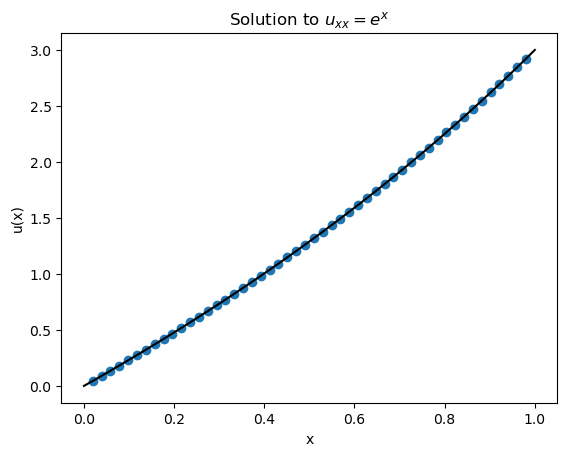

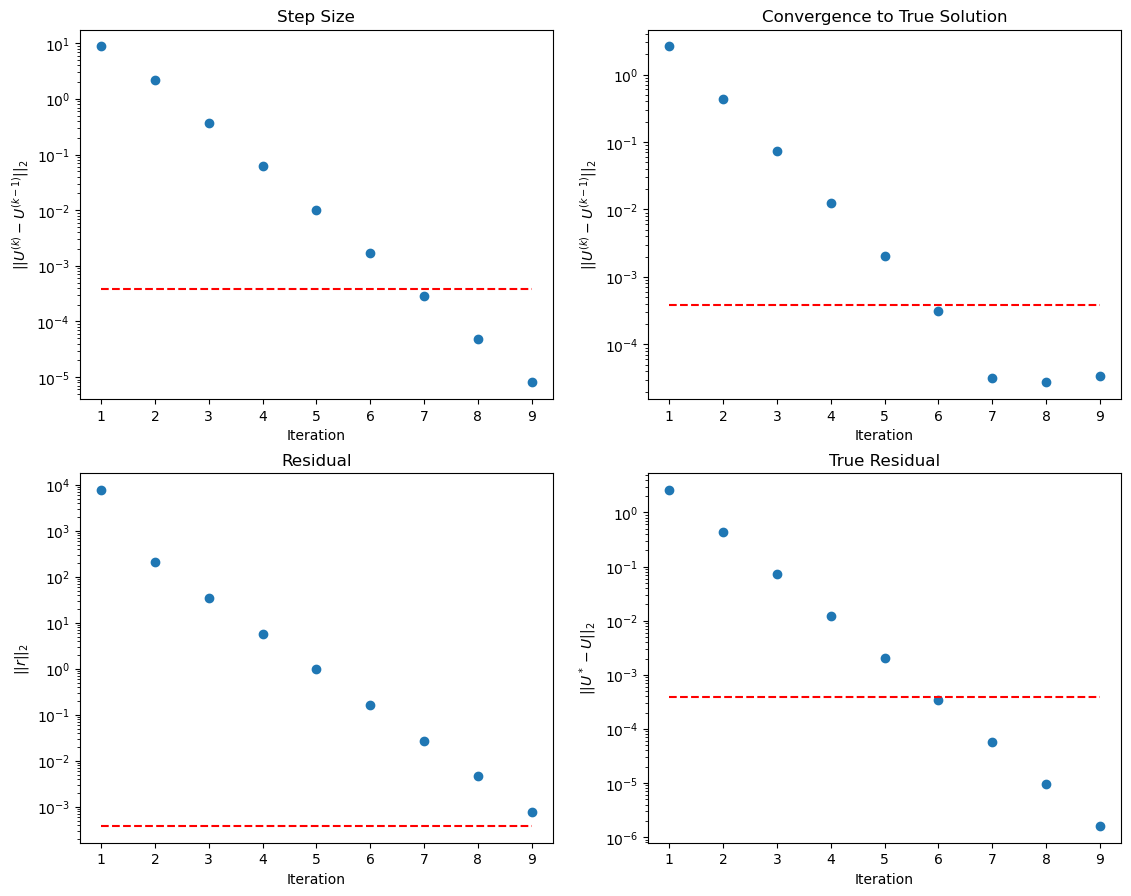

In [39]:
# Problem setup
a = 0.0                              # batas kiri
b = 1.0                              # batas kanan
alpha = 0.0                          # boundary kiri
beta = 3.0                           # boundary kanan

f = lambda x: numpy.exp(x)           # fungsi sumber
u_true = lambda x: (4.0 - numpy.exp(1.0)) * x - 1.0 + numpy.exp(x)  # solusi eksak

# Descretization
m = 50
x_bc = numpy.linspace(a, b, m + 2)   # grid lengkap
x = x_bc[1:-1]                       # titik interior
delta_x = (b - a) / (m + 1)          # jarak grid

# Construct matrix A
A = numpy.zeros((m, m))              # matriks sistem
diagonal = numpy.ones(m) / delta_x**2

A += numpy.diag(diagonal * 2.0, 0)   # diagonal utama
A += numpy.diag(-diagonal[:-1], 1)   # diagonal atas
A += numpy.diag(-diagonal[:-1], -1)  # diagonal bawah

# Construct right hand side
b = -f(x)                            # RHS
b[0] += alpha / delta_x**2           # efek boundary kiri
b[-1] += beta / delta_x**2           # efek boundary kanan

# True solution to system
U_true = numpy.linalg.solve(A, b)    # solusi sistem linear (referensi)

# Algorithm parameters
MAX_CYCLES = 50                      # jumlah V-cycle
tolerance = delta_x**2               # toleransi konvergensi

# Perform multi-grid
U = numpy.zeros(m)                   # initial guess
convergence_MG = numpy.zeros(MAX_CYCLES)
step_size_MG = numpy.zeros(MAX_CYCLES)
residual_norm = numpy.zeros(MAX_CYCLES)
system_convergence = numpy.zeros(MAX_CYCLES)
success = False

for k in range(MAX_CYCLES):
    U_old = U.copy()                 # simpan solusi lama
    
    # Compute residual
    r = b - numpy.dot(A, U)          # residual
    if numpy.linalg.norm(r, ord=2) < tolerance:
        success = True
        break       
    
    U += vcycle(A, r)                # update solusi dengan koreksi multigrid
    
    # Convergence measures
    convergence_MG[k] = numpy.linalg.norm(u_true(x) - U, ord=2)   # error ke solusi eksak
    residual_norm[k] = numpy.linalg.norm(r, ord=2)                # norma residual
    step_size_MG[k] = numpy.linalg.norm(U - U_old, ord=2)         # perubahan solusi
    system_convergence[k] = numpy.linalg.norm(U_true - U, ord=2)  # error ke solusi sistem

if not success:
    print("Iteration failed to converge!")
    print(residual_norm[-10:])
    print(convergence_MG[-10:])   # FIX: tadinya convergence_CG (salah variabel)
else:
    # Plot result
    fig = plt.figure()
    axes = fig.add_subplot(1, 1, 1)
    axes.plot(x, U, 'o', label="Computed")        # solusi numerik
    axes.plot(x_bc, u_true(x_bc), 'k', label="True")  # solusi eksak
    axes.set_title("Solution to $u_{xx} = e^x$")
    axes.set_xlabel("x")
    axes.set_ylabel("u(x)")

    fig = plt.figure()
    fig.set_figwidth(fig.get_figwidth() * 2.1)
    fig.set_figheight(fig.get_figheight() * 2.2)
    
    axes = fig.add_subplot(2, 2, 1)
    axes.semilogy(numpy.arange(1, k + 1), step_size_MG[:k], 'o')
    axes.semilogy(numpy.arange(1, k + 1), numpy.ones(k) * delta_x**2, 'r--')
    axes.set_title("Step Size")
    axes.set_xlabel("Iteration")
    axes.set_ylabel("$||U^{(k)} - U^{(k-1)}||_2$")
    
    axes = fig.add_subplot(2, 2, 2)
    axes.semilogy(numpy.arange(1, k + 1), convergence_MG[:k], 'o')
    axes.semilogy(numpy.arange(1, k + 1), numpy.ones(k) * delta_x**2, 'r--')
    axes.set_title("Convergence to True Solution")
    axes.set_xlabel("Iteration")
    axes.set_ylabel("$||U^{(k)} - U^{(k-1)}||_2$")

    axes = fig.add_subplot(2, 2, 3)
    axes.semilogy(numpy.arange(1, k + 1), residual_norm[:k], 'o')
    axes.semilogy(numpy.arange(1, k + 1), numpy.ones(k) * delta_x**2, 'r--')
    axes.set_title("Residual")
    axes.set_xlabel("Iteration")
    axes.set_ylabel("$||r||_2$")

    axes = fig.add_subplot(2, 2, 4)
    axes.semilogy(numpy.arange(1, k + 1), system_convergence[:k], 'o')
    axes.semilogy(numpy.arange(1, k + 1), numpy.ones(k) * delta_x**2, 'r--')
    axes.set_title("True Residual")
    axes.set_xlabel("Iteration")
    axes.set_ylabel("$||U^* - U||_2$")
    
    print("Matrix condition number = %s" % 
          (numpy.sqrt(numpy.linalg.norm(A) * numpy.linalg.norm(numpy.linalg.inv(A)))))  
    # estimasi kondisi matriks
    
    plt.show()

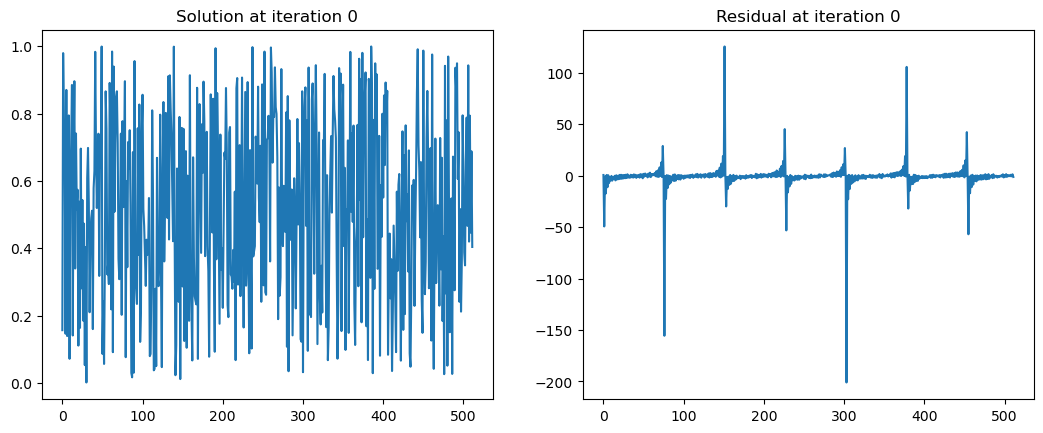

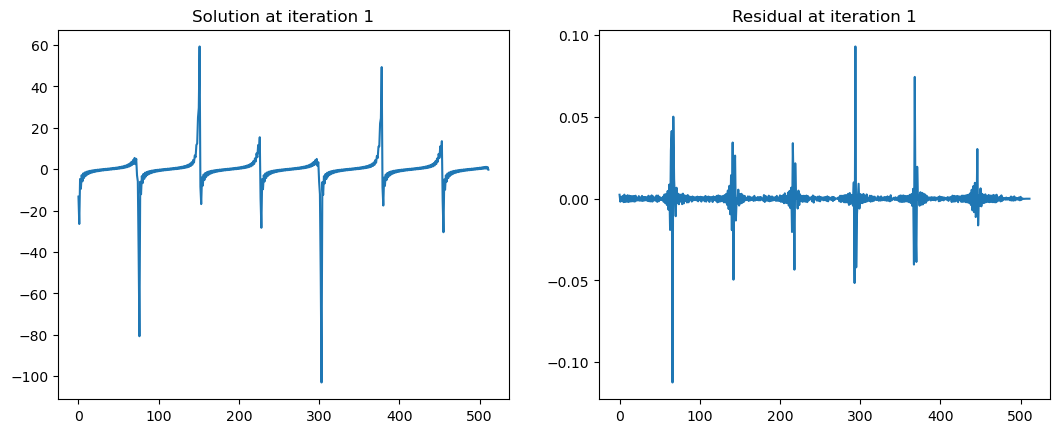

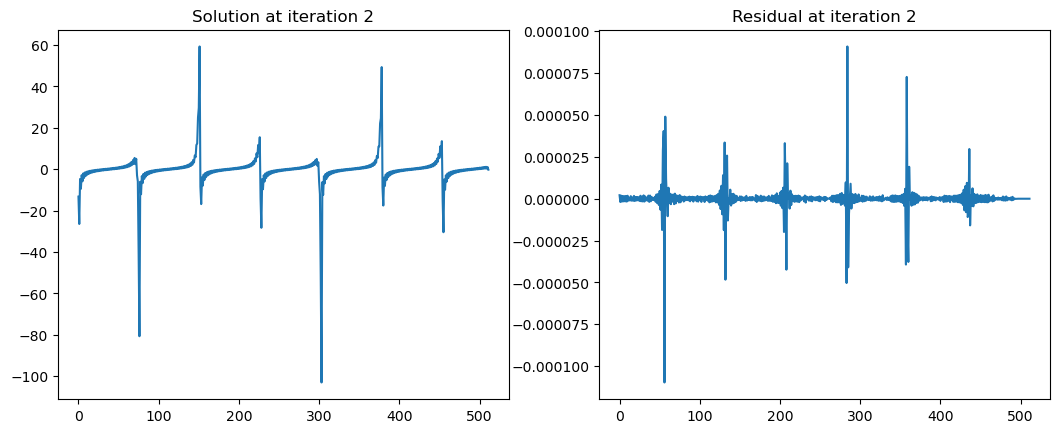

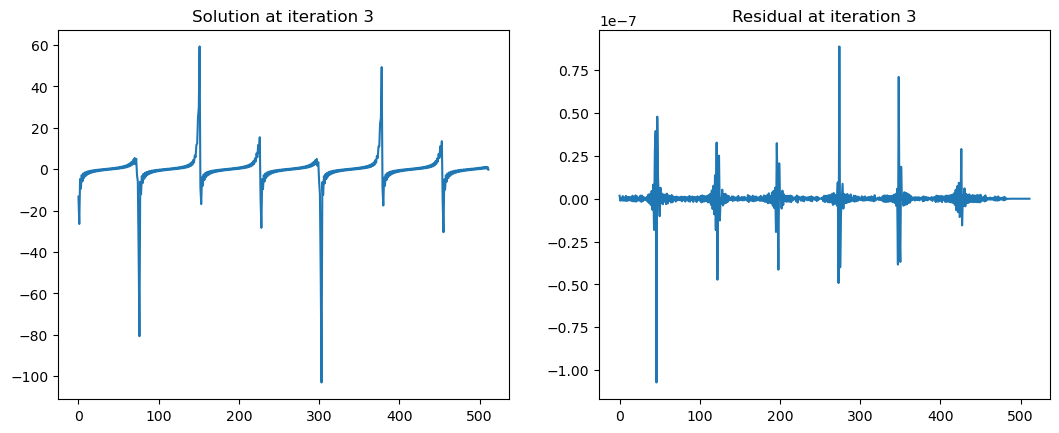

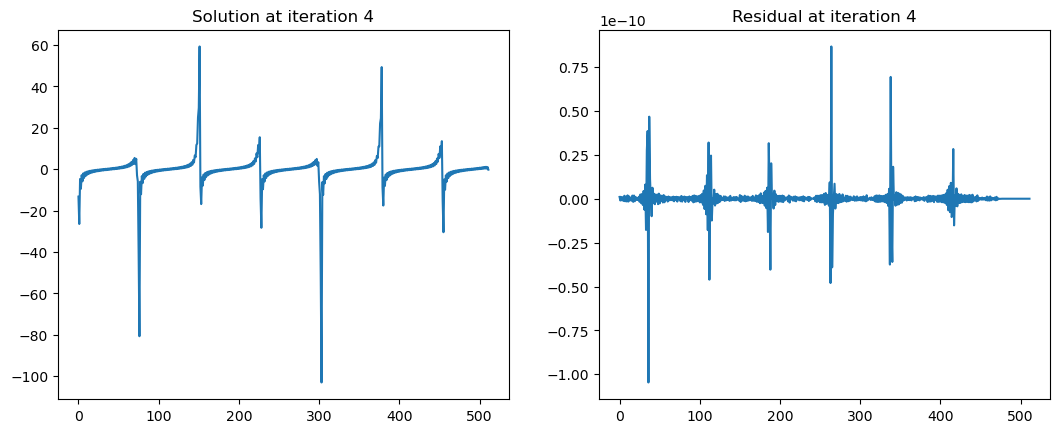

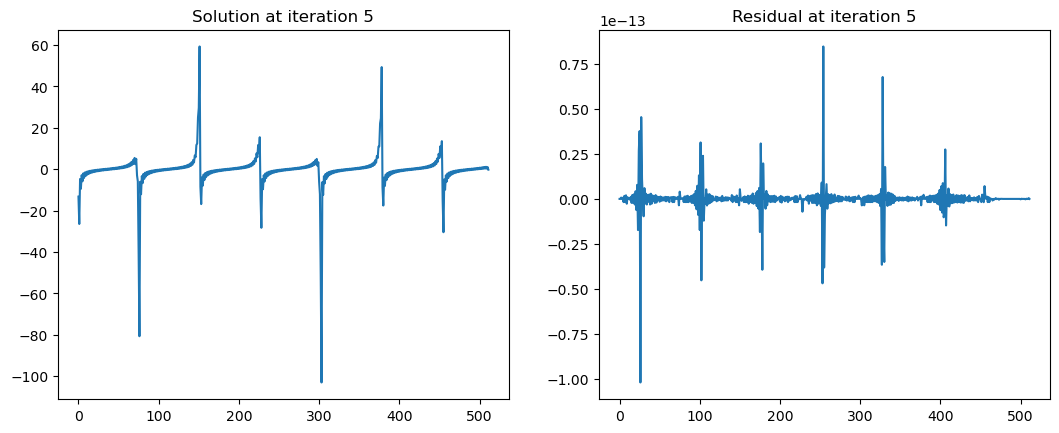

In [40]:
# Slightly harder problem
L = 1.0                              # panjang domain
m = 512                              # jumlah grid (besar → lebih sulit)

x_bc = numpy.linspace(0, L, m + 2)   # grid lengkap
x = x_bc[1:-1]                       # titik interior
delta_x = (b - a) / (m + 1)          # ⚠️ pakai b,a lama → sebaiknya pakai L

# Construct matrix A
A = numpy.diag(2.0 * numpy.ones(m)) \
    - numpy.diag(numpy.ones(m - 1),  1) / L**2  
# ⚠️ ini TIDAK simetris (harusnya ada diagonal bawah juga)

# Right-hand side
b = numpy.tan(numpy.arange(m) / (2 * numpy.pi) * 10)  
# fungsi RHS (acak/nonlinear → lebih sulit dikonvergensikan)

# True solution (referensi)
U_true = numpy.linalg.solve(A, b)    # solusi eksak sistem linear

U = numpy.random.random(m)           # initial guess acak

MAX_CYCLES = 50                      # jumlah iterasi multigrid
tolerance = 1e-10                    # toleransi sangat kecil

for k in range(MAX_CYCLES):
    r = b - numpy.dot(A, U)          # residual

    # Plot setiap iterasi
    fig = plt.figure()
    fig.set_figwidth(fig.get_figwidth() * 2)

    axes = fig.add_subplot(1, 2, 1)
    axes.plot(U)                     # solusi saat ini
    axes.set_title("Solution at iteration %s" % k)

    axes = fig.add_subplot(1, 2, 2)
    axes.plot(r)                     # residual
    axes.set_title("Residual at iteration %s" % k)
    
    if numpy.linalg.norm(r) < tolerance:  # cek konvergensi
        break       

    U += vcycle(A, r)                # update solusi dengan multigrid correction